In [1]:
# [CELL 1] - Updated with Seaborn import
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import logging
from datetime import datetime, timedelta, timezone

# Setup logging (avoid duplicate configs)
if not logging.getLogger().handlers:
    logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Configure Seaborn style
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.facecolor'] = 'white'

# Configuration
LIGHTER_FILE = "lighter_assessment_data.csv"  # From test2.py output
SPOT_FILE = "spot_fx_control_data.csv"
DAYS_TO_FETCH = 30
INTERVAL = "5m"

# MAPPING: Assignment Pair -> Yahoo Ticker
TICKERS = {
    "EURUSD=X": "EURUSD",
    "GBPUSD=X": "GBPUSD",
    "JPY=X": "USDJPY" 
}

logger.info("Configuration loaded successfully")

def fetch_assignment_spot_data():
    logger.info(f"Fetching Spot FX data for {list(TICKERS.values())}...")
    
    end_date = datetime.now()
    start_date = end_date - timedelta(days=DAYS_TO_FETCH)

    # Download data
    raw_data = yf.download(
        list(TICKERS.keys()), 
        start=start_date, 
        end=end_date, 
        interval=INTERVAL, 
        group_by='ticker',
        progress=True
    )

    if raw_data.empty:
        logger.error("No data returned from Yahoo Finance.")
        return

    all_rows = []

    # Process each ticker
    for yahoo_symbol, clean_name in TICKERS.items():
        try:
            # Handle multi-index dataframe from yfinance
            if len(TICKERS) > 1:
                df = raw_data[yahoo_symbol][['Close']].copy()
            else:
                df = raw_data[['Close']].copy()

            df.columns = ['close']
            df['symbol'] = clean_name
            
            # Reset index to make Timestamp a column
            df = df.reset_index()
            
            # Standardize Timestamp column name
            if 'Datetime' in df.columns:
                df.rename(columns={'Datetime': 'timestamp_iso'}, inplace=True)
            elif 'Date' in df.columns:
                df.rename(columns={'Date': 'timestamp_iso'}, inplace=True)

            # Ensure UTC
            if df['timestamp_iso'].dt.tz is None:
                df['timestamp_iso'] = df['timestamp_iso'].dt.tz_localize('UTC')
            else:
                df['timestamp_iso'] = df['timestamp_iso'].dt.tz_convert('UTC')

            # Create Unix Timestamp (milliseconds) for matching with Lighter
            df['timestamp_unix_ms'] = df['timestamp_iso'].astype('int64') // 10**6
            
            all_rows.append(df)
            
        except KeyError as e:
            logger.warning(f"Could not process {yahoo_symbol}: {e}")

    # Combine all into one DataFrame
    final_df = pd.concat(all_rows)
    
    # Sort
    final_df.sort_values(by=['symbol', 'timestamp_unix_ms'], inplace=True)

    # Save
    final_df.to_csv(SPOT_FILE, index=False)
    
    logger.info("-" * 40)
    logger.info(f"✔ SUCCESS: Saved {len(final_df)} rows to {SPOT_FILE}")
    logger.info("  Included: EURUSD, GBPUSD, USDJPY")
    logger.info("  Note: Remember that Spot markets close on weekends (Fri 22:00 - Sun 21:00 UTC).")
    logger.info("        Gaps in this file during weekends are EXPECTED and CORRECT.")
    logger.info("-" * 40)

if __name__ == "__main__":
    fetch_assignment_spot_data()

2025-12-06 19:41:39,584 - INFO - Configuration loaded successfully
2025-12-06 19:41:39,585 - INFO - Fetching Spot FX data for ['EURUSD', 'GBPUSD', 'USDJPY']...
2025-12-06 19:41:39,585 - INFO - Fetching Spot FX data for ['EURUSD', 'GBPUSD', 'USDJPY']...
/tmp/ipykernel_9435/1896946796.py:43: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(
/tmp/ipykernel_9435/1896946796.py:43: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(
[*********************100%***********************]  3 of 3 completed
2025-12-06 19:41:41,339 - INFO - ----------------------------------------
2025-12-06 19:41:41,339 - INFO - ✔ SUCCESS: Saved 18030 rows to spot_fx_control_data.csv
2025-12-06 19:41:41,339 - INFO -   Included: EURUSD, GBPUSD, USDJPY
2025-12-06 19:41:41,340 - INFO -   Note: Remember that Spot markets close on weekends (Fri 22:00 - Sun 21:00 UTC).
2025-12-06 19:41:41,340 - INFO -         Gaps in

In [2]:
# [CELL 2] - Load and Process Data with Better Error Handling (FIXED)
try:
    # Check file existence
    files_exist = []
    
    if os.path.exists(SPOT_FILE):
        logger.info(f"✅ Found spot data: {SPOT_FILE}")
        files_exist.append('spot')
    else:
        logger.error(f"Spot data file {SPOT_FILE} not found!")
        logger.info("Running spot data fetch automatically...")
        fetch_spot_data()  # Auto-fetch if file doesn't exist
        if os.path.exists(SPOT_FILE):
            files_exist.append('spot')
        
    if os.path.exists(LIGHTER_FILE):
        logger.info(f"Found Lighter data: {LIGHTER_FILE}")
        files_exist.append('lighter')
    else:
        logger.warning(f"⚠️  Lighter data file {LIGHTER_FILE} not found")
        logger.info("To get Lighter data, run: python test2.py")

    if 'spot' not in files_exist:
        logger.error("Cannot proceed without spot data. Data fetch failed.")
        raise FileNotFoundError("Spot data required but fetch failed")

    # Load spot data
    logger.info("Loading datasets...")
    df_s = pd.read_csv(SPOT_FILE)
    logger.info(f"Spot data shape: {df_s.shape}")
    logger.info(f"Spot columns: {df_s.columns.tolist()}")
    
    # Process spot data - handle multiple timestamp formats
    timestamp_col = None
    for col_name in ['timestamp', 'timestamp_iso', 'Datetime', 'Date']:
        if col_name in df_s.columns:
            timestamp_col = col_name
            break
    
    if timestamp_col is None:
        logger.error("No timestamp column found in spot data")
        logger.error(f"Available columns: {df_s.columns.tolist()}")
        raise ValueError("Missing timestamp column")
    
    logger.info(f"Using timestamp column: {timestamp_col}")
    
    # Standardize timestamp column name for processing
    if timestamp_col != 'timestamp':
        df_s['timestamp'] = df_s[timestamp_col]
    
    # Convert to datetime
    df_s['timestamp'] = pd.to_datetime(df_s['timestamp'], utc=True)
    
    # Create wide format for spot data
    if 'symbol' in df_s.columns:
        logger.info(f"Spot symbols: {df_s['symbol'].unique()}")
        spot_wide = df_s.pivot(index='timestamp', columns='symbol', values='close').add_prefix('S_')
        # Remove any NaN columns
        spot_wide = spot_wide.dropna(axis=1, how='all')
    else:
        # Fallback for single symbol data
        spot_wide = df_s.set_index('timestamp')[['close']].rename(columns={'close': 'S_EURUSD'})

    logger.info(f"Spot wide format shape: {spot_wide.shape}")
    logger.info(f"Spot wide columns: {spot_wide.columns.tolist()}")

    # Try to load Lighter data if available
    if 'lighter' in files_exist:
        try:
            df_l = pd.read_csv(LIGHTER_FILE)
            logger.info(f"Lighter data shape: {df_l.shape}")
            logger.info(f"Lighter columns: {df_l.columns.tolist()}")
            
            # Process Lighter data timestamp - handle multiple formats
            l_timestamp_col = None
            for col_name in ['timestamp', 'timestamp_iso', 'Datetime', 'Date']:
                if col_name in df_l.columns:
                    l_timestamp_col = col_name
                    break
            
            if l_timestamp_col is None:
                logger.warning("No timestamp column in Lighter data")
                lighter_wide = pd.DataFrame()
            else:
                # Standardize timestamp column name for processing
                if l_timestamp_col != 'timestamp':
                    df_l['timestamp'] = df_l[l_timestamp_col]
                
                df_l['timestamp'] = pd.to_datetime(df_l['timestamp'], utc=True)
                
                if 'symbol' in df_l.columns:
                    logger.info(f"Lighter symbols: {df_l['symbol'].unique()}")
                    lighter_wide = df_l.pivot(index='timestamp', columns='symbol', values='close').add_prefix('L_')
                else:
                    # Look for price columns
                    price_cols = [col for col in df_l.columns if any(keyword in col.lower() 
                                 for keyword in ['price', 'close', 'mid', 'last'])]
                    if price_cols:
                        lighter_wide = df_l.set_index('timestamp')[price_cols[:1]].rename(
                            columns={price_cols[0]: 'L_EURUSD'})
                    else:
                        logger.warning("No recognizable price columns in Lighter data")
                        lighter_wide = pd.DataFrame()
            u
            # Merge datasets if we have both
            if not lighter_wide.empty and not spot_wide.empty:
                logger.info("Merging Lighter and Spot data...")
                # Ensure indices are sorted
                lighter_wide = lighter_wide.sort_index()
                spot_wide = spot_wide.sort_index()
                
                # Use merge_asof to combine time series
                df = pd.merge_asof(
                    lighter_wide.reset_index().sort_values('timestamp'), 
                    spot_wide.reset_index().sort_values('timestamp'), 
                    on='timestamp', 
                    direction='backward',
                    tolerance=pd.Timedelta("10m")
                ).set_index('timestamp')
                
                data_source = "Combined (Lighter + Spot)"
            else:
                df = spot_wide.copy()
                data_source = "Spot only (no valid Lighter data)"
                
        except Exception as e:
            logger.warning(f"Error processing Lighter data: {e}")
            import traceback
            traceback.print_exc()
            df = spot_wide.copy()
            data_source = "Spot only (Lighter data error)"
    else:
        df = spot_wide.copy()
        data_source = "Spot only (no Lighter file)"

    # Ensure we have data
    if df.empty:
        raise ValueError("No data available after processing")

    # Add time-based features
    df['day'] = df.index.dayofweek
    df['hour'] = df.index.hour
    df['is_weekend'] = (
        (df['day'] == 5) |  # Saturday
        ((df['day'] == 4) & (df['hour'] >= 22)) |  # Friday after 10 PM
        ((df['day'] == 6) & (df['hour'] <= 20))    # Sunday before 8 PM
    )
    
    # Filter for weekend data
    weekend_df = df[df['is_weekend'] == True].copy()
    
    # Summary output
    print("\n" + "="*60)
    print("📊 DATA SUMMARY")
    print("="*60)
    print(f"Data source: {data_source}")
    print(f"Total observations: {len(df):,}")
    print(f"Weekend observations: {len(weekend_df):,}")
    print(f"Date range: {df.index.min()} to {df.index.max()}")
    print(f"Available columns: {df.columns.tolist()}")
    
    if len(df) > 0:
        print(f"\nLatest data sample:")
        print(df.tail())
        
        # Show data completeness
        print(f"\nData completeness:")
        for col in df.columns:
            if col.startswith(('S_', 'L_')):
                non_null_count = df[col].count()
                completeness = (non_null_count / len(df)) * 100
                print(f"  {col}: {non_null_count:,} / {len(df):,} ({completeness:.1f}%)")
        
    if len(weekend_df) > 0:
        print(f"\n✅ Weekend data available for analysis: {len(weekend_df):,} observations")
    else:
        print(f"\n⚠️  No weekend data found in current time range")
        print("   Consider extending the date range or checking weekend definition")
    
    print("="*60)
    
except Exception as e:
    logger.error(f"Error in data processing: {e}")
    import traceback
    traceback.print_exc()

2025-12-06 19:41:41,353 - INFO - ✅ Found spot data: spot_fx_control_data.csv
2025-12-06 19:41:41,354 - INFO - Found Lighter data: lighter_assessment_data.csv
2025-12-06 19:41:41,354 - INFO - Loading datasets...
2025-12-06 19:41:41,354 - INFO - Found Lighter data: lighter_assessment_data.csv
2025-12-06 19:41:41,354 - INFO - Loading datasets...
2025-12-06 19:41:41,412 - INFO - Spot data shape: (18030, 4)
2025-12-06 19:41:41,412 - INFO - Spot columns: ['timestamp_iso', 'close', 'symbol', 'timestamp_unix_ms']
2025-12-06 19:41:41,412 - INFO - Using timestamp column: timestamp_iso
2025-12-06 19:41:41,412 - INFO - Spot data shape: (18030, 4)
2025-12-06 19:41:41,412 - INFO - Spot columns: ['timestamp_iso', 'close', 'symbol', 'timestamp_unix_ms']
2025-12-06 19:41:41,412 - INFO - Using timestamp column: timestamp_iso
2025-12-06 19:41:41,482 - INFO - Spot symbols: ['EURUSD' 'GBPUSD' 'USDJPY']
2025-12-06 19:41:41,482 - INFO - Spot symbols: ['EURUSD' 'GBPUSD' 'USDJPY']
2025-12-06 19:41:41,517 - INF


📊 DATA SUMMARY
Data source: Spot only (Lighter data error)
Total observations: 6,010
Weekend observations: 30
Date range: 2025-11-06 19:40:00+00:00 to 2025-12-05 22:25:00+00:00
Available columns: ['S_EURUSD', 'S_GBPUSD', 'S_USDJPY', 'day', 'hour', 'is_weekend']

Latest data sample:
symbol                     S_EURUSD  S_GBPUSD  S_USDJPY  day  hour  is_weekend
timestamp                                                                     
2025-12-05 22:05:00+00:00  1.164551  1.333031       NaN    4    22        True
2025-12-05 22:10:00+00:00  1.164551  1.333031       NaN    4    22        True
2025-12-05 22:15:00+00:00  1.164551  1.333031       NaN    4    22        True
2025-12-05 22:20:00+00:00  1.164551  1.333031       NaN    4    22        True
2025-12-05 22:25:00+00:00  1.164551  1.333031       NaN    4    22        True

Data completeness:
  S_EURUSD: 6,010 / 6,010 (100.0%)
  S_GBPUSD: 6,010 / 6,010 (100.0%)
  S_USDJPY: 5,980 / 6,010 (99.5%)

✅ Weekend data available for analysis:

Traceback (most recent call last):
  File "/tmp/ipykernel_9435/3643820024.py", line 104, in <module>
    u
NameError: name 'u' is not defined


In [3]:
# [CELL 3] - Load and Process Data with Better Error Handling (FINAL FIX)
try:
    # Check file existence
    files_exist = []
    
    if os.path.exists(SPOT_FILE):
        logger.info(f"✅ Found spot data: {SPOT_FILE}")
        files_exist.append('spot')
    else:
        logger.error(f"ERROR: Spot data file {SPOT_FILE} not found!")
        logger.info("Running spot data fetch automatically...")
        fetch_spot_data()  # Auto-fetch if file doesn't exist
        if os.path.exists(SPOT_FILE):
            files_exist.append('spot')
        
    if os.path.exists(LIGHTER_FILE):
        logger.info(f"Found Lighter data: {LIGHTER_FILE}")
        files_exist.append('lighter')
    else:
        logger.warning(f"⚠️  Lighter data file {LIGHTER_FILE} not found")
        logger.info("To get Lighter data, run: python test2.py")

    if 'spot' not in files_exist:
        logger.error("Cannot proceed without spot data. Data fetch failed.")
        raise FileNotFoundError("Spot data required but fetch failed")

    # Load spot data
    logger.info("Loading datasets...")
    df_s = pd.read_csv(SPOT_FILE)
    logger.info(f"Spot data shape: {df_s.shape}")
    logger.info(f"Spot columns: {df_s.columns.tolist()}")
    
    # Process spot data - handle multiple timestamp formats
    timestamp_col = None
    for col_name in ['timestamp', 'timestamp_iso', 'Datetime', 'Date']:
        if col_name in df_s.columns:
            timestamp_col = col_name
            break
    
    if timestamp_col is None:
        logger.error("No timestamp column found in spot data")
        logger.error(f"Available columns: {df_s.columns.tolist()}")
        raise ValueError("Missing timestamp column")
    
    logger.info(f"Using timestamp column: {timestamp_col}")
    
    # Standardize timestamp column name
    if timestamp_col != 'timestamp':
        df_s['timestamp'] = df_s[timestamp_col]
    
    # Convert to datetime
    df_s['timestamp'] = pd.to_datetime(df_s['timestamp'], utc=True)
    
    # Create wide format for spot data
    if 'symbol' in df_s.columns:
        logger.info(f"Spot symbols: {df_s['symbol'].unique()}")
        spot_wide = df_s.pivot(index='timestamp', columns='symbol', values='close').add_prefix('S_')
        # Remove any NaN columns
        spot_wide = spot_wide.dropna(axis=1, how='all')
    else:
        # Fallback for single symbol data
        spot_wide = df_s.set_index('timestamp')[['close']].rename(columns={'close': 'S_EURUSD'})

    logger.info(f"Spot wide format shape: {spot_wide.shape}")
    logger.info(f"Spot wide columns: {spot_wide.columns.tolist()}")

    # Try to load Lighter data if available
    if 'lighter' in files_exist:
        try:
            df_l = pd.read_csv(LIGHTER_FILE)
            logger.info(f"Lighter data shape: {df_l.shape}")
            logger.info(f"Lighter columns: {df_l.columns.tolist()}")
            
            # Process Lighter data timestamp
            l_timestamp_col = None
            for col_name in ['timestamp', 'timestamp_iso', 'Datetime', 'Date']:
                if col_name in df_l.columns:
                    l_timestamp_col = col_name
                    break
            
            if l_timestamp_col is None:
                logger.warning("No timestamp column in Lighter data")
                lighter_wide = pd.DataFrame()
            else:
                # Standardize timestamp column name
                if l_timestamp_col != 'timestamp':
                    df_l['timestamp'] = df_l[l_timestamp_col]
                
                df_l['timestamp'] = pd.to_datetime(df_l['timestamp'], utc=True)
                
                if 'symbol' in df_l.columns:
                    logger.info(f"Lighter symbols: {df_l['symbol'].unique()}")
                    lighter_wide = df_l.pivot(index='timestamp', columns='symbol', values='close').add_prefix('L_')
                else:
                    # Look for price columns
                    price_cols = [col for col in df_l.columns if any(keyword in col.lower() 
                                 for keyword in ['price', 'close', 'mid', 'last'])]
                    if price_cols:
                        lighter_wide = df_l.set_index('timestamp')[price_cols[:1]].rename(
                            columns={price_cols[0]: 'L_EURUSD'})
                    else:
                        logger.warning("No recognizable price columns in Lighter data")
                        lighter_wide = pd.DataFrame()
            
            # Merge datasets if we have both
            if not lighter_wide.empty and not spot_wide.empty:
                logger.info("Merging Lighter and Spot data...")
                # Ensure indices are sorted
                lighter_wide = lighter_wide.sort_index()
                spot_wide = spot_wide.sort_index()
                
                # Use merge_asof to combine time series
                df = pd.merge_asof(
                    lighter_wide.reset_index().sort_values('timestamp'), 
                    spot_wide.reset_index().sort_values('timestamp'), 
                    on='timestamp', 
                    direction='backward',
                    tolerance=pd.Timedelta("10m")
                ).set_index('timestamp')
                
                data_source = "Combined (Lighter + Spot)"
            else:
                df = spot_wide.copy()
                data_source = "Spot only (no valid Lighter data)"
                
        except Exception as e:
            logger.warning(f"Error processing Lighter data: {e}")
            import traceback
            traceback.print_exc()
            df = spot_wide.copy()
            data_source = "Spot only (Lighter data error)"
    else:
        df = spot_wide.copy()
        data_source = "Spot only (no Lighter file)"

    # Ensure we have data
    if df.empty:
        raise ValueError("No data available after processing")

    # Add time-based features
    df['day'] = df.index.dayofweek
    df['hour'] = df.index.hour
    df['is_weekend'] = (
        (df['day'] == 5) |  # Saturday
        ((df['day'] == 4) & (df['hour'] >= 22)) |  # Friday after 10 PM
        ((df['day'] == 6) & (df['hour'] <= 20))    # Sunday before 8 PM
    )
    
    # Filter for weekend data
    weekend_df = df[df['is_weekend'] == True].copy()
    
    # Summary output
    print("\n" + "="*60)
    print("📊 DATA SUMMARY")
    print("="*60)
    print(f"Data source: {data_source}")
    print(f"Total observations: {len(df):,}")
    print(f"Weekend observations: {len(weekend_df):,}")
    print(f"Date range: {df.index.min()} to {df.index.max()}")
    print(f"Available columns: {df.columns.tolist()}")
    
    if len(df) > 0:
        print(f"\nLatest data sample:")
        print(df.tail())
        
        # Show data completeness
        print(f"\nData completeness:")
        for col in df.columns:
            if col.startswith(('S_', 'L_')):
                non_null_count = df[col].count()
                completeness = (non_null_count / len(df)) * 100
                print(f"  {col}: {non_null_count:,} / {len(df):,} ({completeness:.1f}%)")
        
    if len(weekend_df) > 0:
        print(f"\n✅ Weekend data available for analysis: {len(weekend_df):,} observations")
    else:
        print(f"\n⚠️  No weekend data found in current time range")
        print("   Consider extending the date range or checking weekend definition")
    
    print("="*60)
    
except Exception as e:
    logger.error(f"Error in data processing: {e}")
    import traceback
    traceback.print_exc()

2025-12-06 19:41:41,820 - INFO - ✅ Found spot data: spot_fx_control_data.csv
2025-12-06 19:41:41,820 - INFO - Found Lighter data: lighter_assessment_data.csv
2025-12-06 19:41:41,820 - INFO - Loading datasets...
2025-12-06 19:41:41,827 - INFO - Spot data shape: (18030, 4)
2025-12-06 19:41:41,820 - INFO - Found Lighter data: lighter_assessment_data.csv
2025-12-06 19:41:41,820 - INFO - Loading datasets...
2025-12-06 19:41:41,827 - INFO - Spot data shape: (18030, 4)
2025-12-06 19:41:41,828 - INFO - Spot columns: ['timestamp_iso', 'close', 'symbol', 'timestamp_unix_ms']
2025-12-06 19:41:41,828 - INFO - Using timestamp column: timestamp_iso
2025-12-06 19:41:41,837 - INFO - Spot symbols: ['EURUSD' 'GBPUSD' 'USDJPY']
2025-12-06 19:41:41,828 - INFO - Spot columns: ['timestamp_iso', 'close', 'symbol', 'timestamp_unix_ms']
2025-12-06 19:41:41,828 - INFO - Using timestamp column: timestamp_iso
2025-12-06 19:41:41,837 - INFO - Spot symbols: ['EURUSD' 'GBPUSD' 'USDJPY']
2025-12-06 19:41:41,840 - INF


📊 DATA SUMMARY
Data source: Combined (Lighter + Spot)
Total observations: 45,149
Weekend observations: 11,757
Date range: 2025-11-04 21:28:00+00:00 to 2025-12-06 05:56:00+00:00
Available columns: ['L_BTC', 'L_ETH', 'L_EURUSD', 'L_GBPUSD', 'L_USDJPY', 'S_EURUSD', 'S_GBPUSD', 'S_USDJPY', 'day', 'hour', 'is_weekend']

Latest data sample:
symbol                       L_BTC    L_ETH  L_EURUSD  L_GBPUSD  L_USDJPY  \
timestamp                                                                   
2025-12-06 05:52:00+00:00  89561.1  3039.04   1.16463   1.33258   155.142   
2025-12-06 05:53:00+00:00  89561.8  3038.65   1.16463   1.33260   155.142   
2025-12-06 05:54:00+00:00  89564.2  3038.42   1.16463   1.33258   155.142   
2025-12-06 05:55:00+00:00  89597.6  3038.38   1.16463   1.33260   155.142   
2025-12-06 05:56:00+00:00  89590.9  3037.80   1.16463   1.33258   155.142   

symbol                     S_EURUSD  S_GBPUSD  S_USDJPY  day  hour  is_weekend  
timestamp                                

Available Lighter columns: ['L_BTC', 'L_ETH', 'L_EURUSD', 'L_GBPUSD', 'L_USDJPY']
Available Spot columns: ['S_EURUSD', 'S_GBPUSD', 'S_USDJPY']


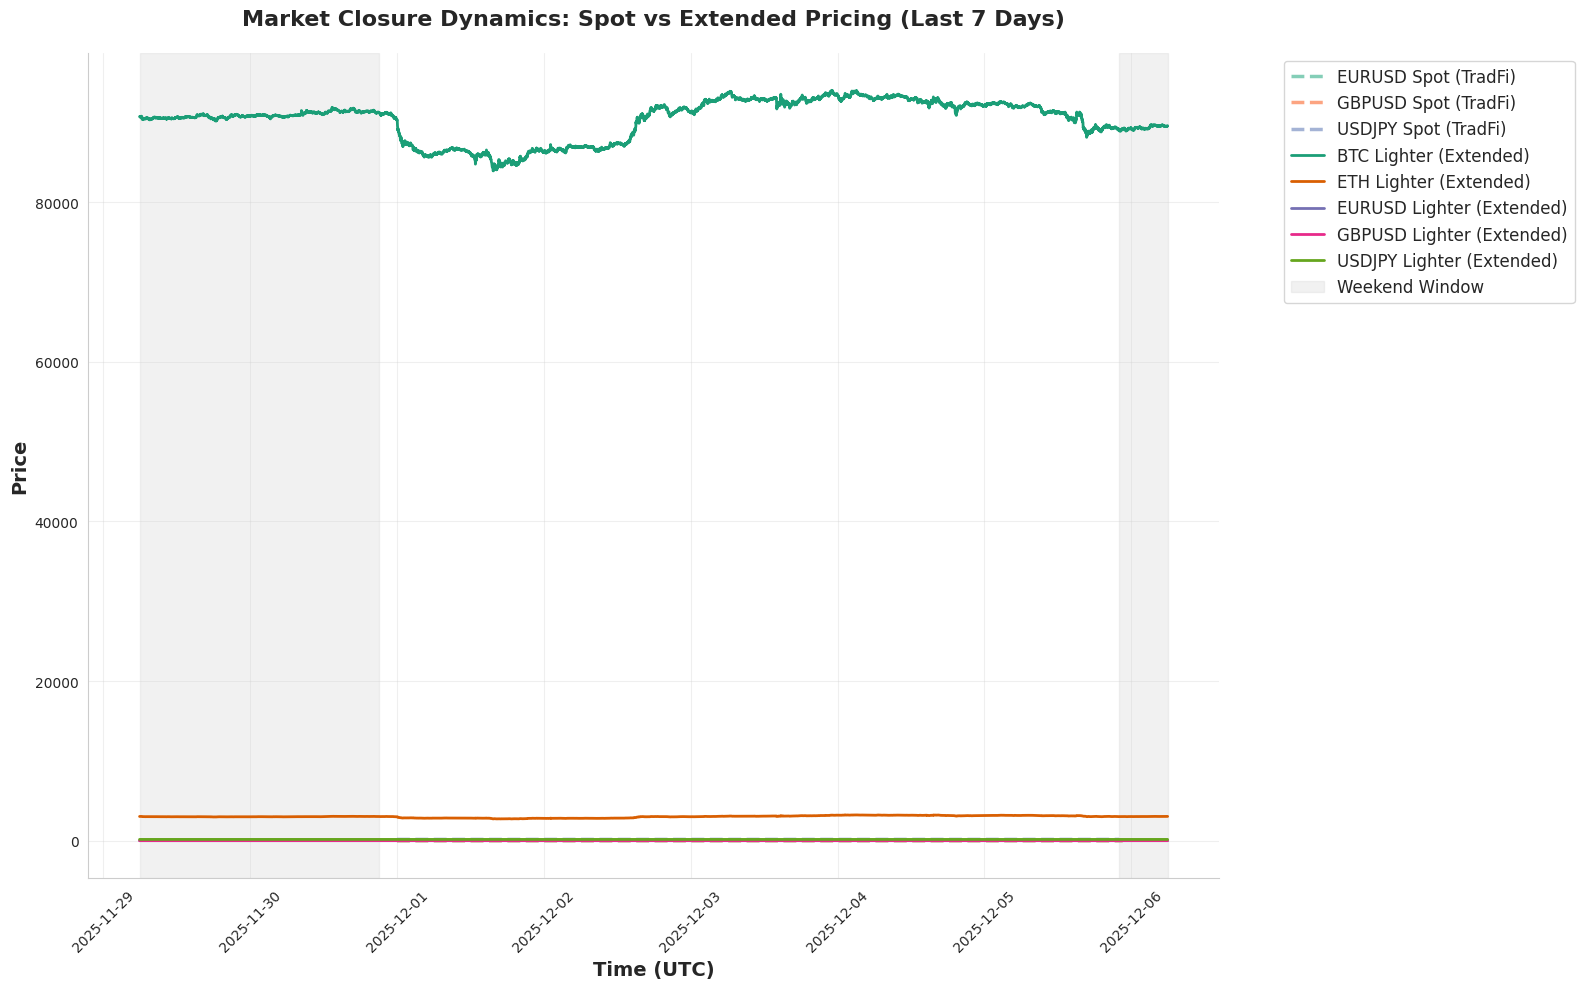

📊 Visualization shows 10,081 data points from last 7 days


In [4]:
# [CELL 4] - Enhanced Visualization with Seaborn
try:
    if 'df' in locals() and len(df) > 0:
        
        # Check available columns
        l_cols = [col for col in df.columns if col.startswith('L_')]
        s_cols = [col for col in df.columns if col.startswith('S_')]
        
        print(f"Available Lighter columns: {l_cols}")
        print(f"Available Spot columns: {s_cols}")
        
        if len(s_cols) > 0:  # At least spot data available
            
            # Use most recent data for visualization (last 7 days)
            recent_cutoff = df.index.max() - timedelta(days=7)
            viz_df = df[df.index >= recent_cutoff].copy()
            
            if len(viz_df) == 0:
                print("No recent data available for visualization")
            else:
                # Set up the plot with Seaborn style
                fig, ax = plt.subplots(figsize=(16, 10))
                
                # Define color palette
                spot_colors = sns.color_palette("Set2", len(s_cols))
                lighter_colors = sns.color_palette("Dark2", len(l_cols))
                
                # Plot spot data with dashed lines
                for i, s_col in enumerate(s_cols):
                    currency = s_col.replace('S_', '')
                    ax.plot(viz_df.index, viz_df[s_col], 
                           label=f'{currency} Spot (TradFi)', 
                           linestyle='--', linewidth=2.5, alpha=0.8,
                           color=spot_colors[i])
                
                # Plot Lighter data with solid lines
                for i, l_col in enumerate(l_cols):
                    currency = l_col.replace('L_', '')
                    ax.plot(viz_df.index, viz_df[l_col], 
                           label=f'{currency} Lighter (Extended)', 
                           linewidth=2, color=lighter_colors[i])
                
                # Highlight weekend periods with a subtle background
                weekend_periods = viz_df[viz_df['is_weekend']].index
                if len(weekend_periods) > 0:
                    # Group consecutive weekend timestamps
                    weekend_starts = []
                    weekend_ends = []
                    
                    current_start = weekend_periods[0]
                    current_end = weekend_periods[0]
                    
                    for i in range(1, len(weekend_periods)):
                        if (weekend_periods[i] - weekend_periods[i-1]).total_seconds() <= 3600:  # Within 1 hour
                            current_end = weekend_periods[i]
                        else:
                            weekend_starts.append(current_start)
                            weekend_ends.append(current_end)
                            current_start = weekend_periods[i]
                            current_end = weekend_periods[i]
                    
                    weekend_starts.append(current_start)
                    weekend_ends.append(current_end)
                    
                    for start, end in zip(weekend_starts, weekend_ends):
                        ax.axvspan(start, end, color='lightgray', alpha=0.3, 
                                  label='Weekend Window' if start == weekend_starts[0] else "")
                
                # Style the plot
                ax.set_title("Market Closure Dynamics: Spot vs Extended Pricing (Last 7 Days)", 
                           fontsize=16, fontweight='bold', pad=20)
                ax.set_ylabel("Price", fontsize=14, fontweight='bold')
                ax.set_xlabel("Time (UTC)", fontsize=14, fontweight='bold')
                
                # Format legend
                ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
                
                # Format x-axis
                plt.xticks(rotation=45)
                ax.grid(True, alpha=0.3)
                
                # Add subtle styling
                ax.spines['top'].set_visible(False)
                ax.spines['right'].set_visible(False)
                
                plt.tight_layout()
                plt.show()
                
                print(f"📊 Visualization shows {len(viz_df):,} data points from last 7 days")
        else:
            print("No data columns available for visualization")
            
    else:
        print("No data available for visualization")
        
except Exception as e:
    logger.error(f"Error in visualization: {e}")
    import traceback
    traceback.print_exc()

Weekend analysis for 11757 observations
Available columns: L_5, S_3

--- BTC Weekend Analysis ---
Volatility (std of returns): 0.00138966
📈 CONCLUSION: Price is DYNAMIC (active movement)
Maximum absolute drift: 19.5834%
Final drift from start: -13.7558%


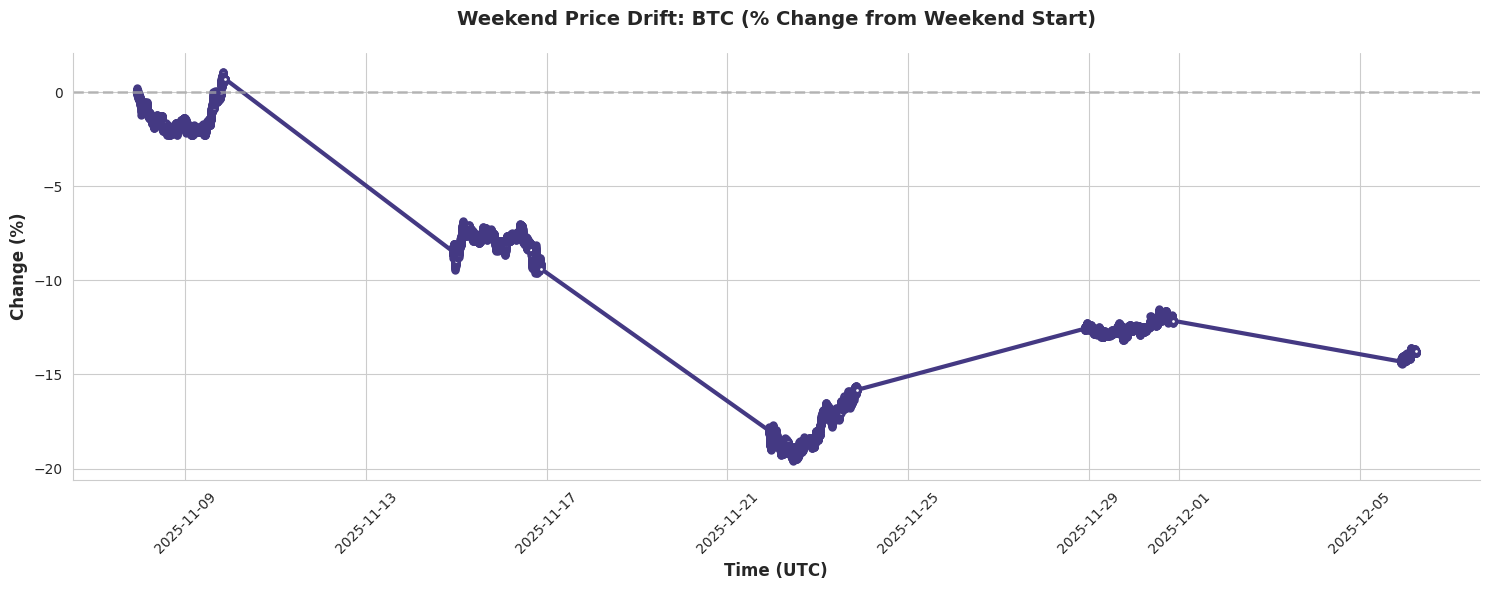


--- ETH Weekend Analysis ---
Volatility (std of returns): 0.00175871
📈 CONCLUSION: Price is DYNAMIC (active movement)
Maximum absolute drift: 21.8663%
Final drift from start: -12.3396%


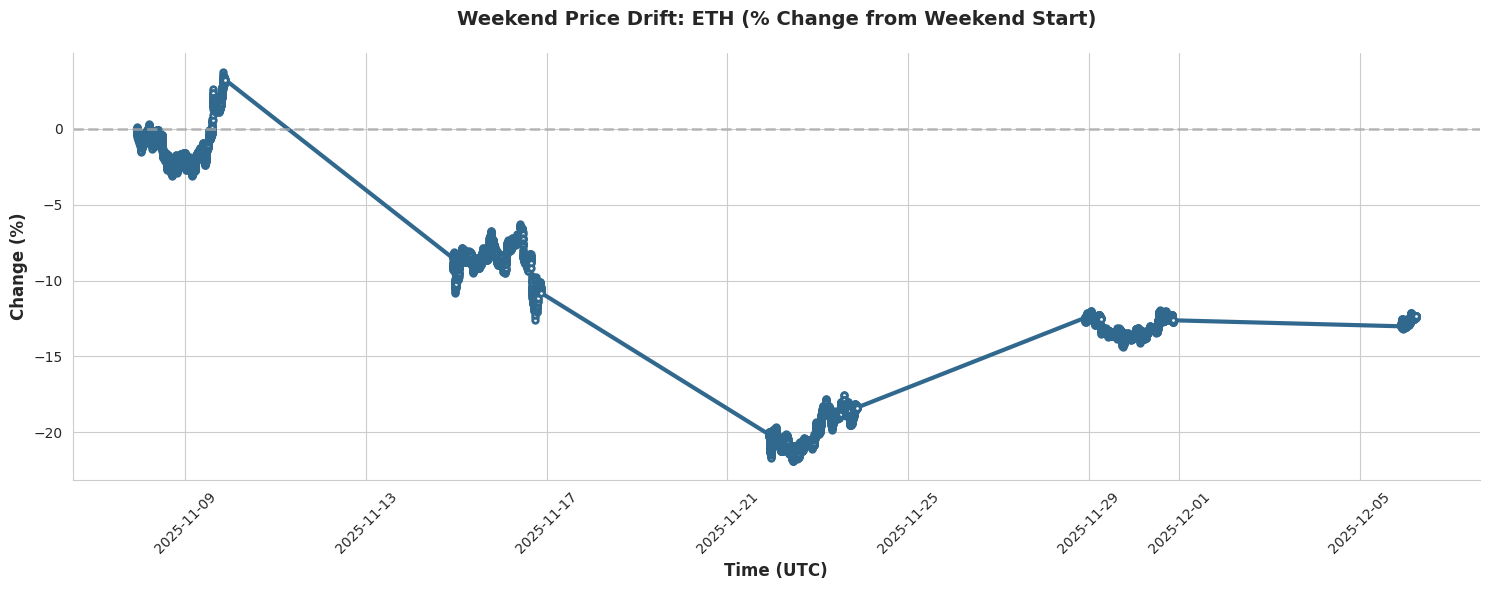


--- EURUSD Weekend Analysis ---
Volatility (std of returns): 0.00013005
📈 CONCLUSION: Price is DYNAMIC (active movement)
Maximum absolute drift: 0.6203%
Final drift from start: 0.6142%


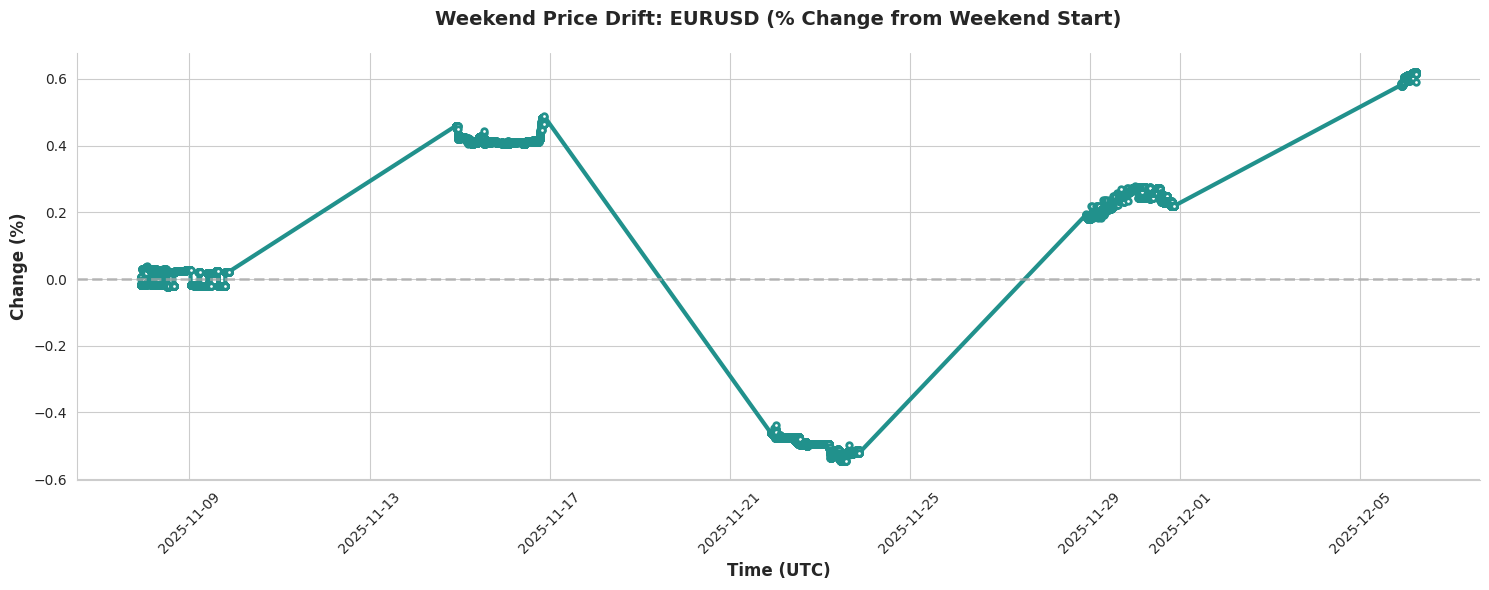


--- GBPUSD Weekend Analysis ---
Volatility (std of returns): 0.00013187
📈 CONCLUSION: Price is DYNAMIC (active movement)
Maximum absolute drift: 1.2934%
Final drift from start: 1.2660%


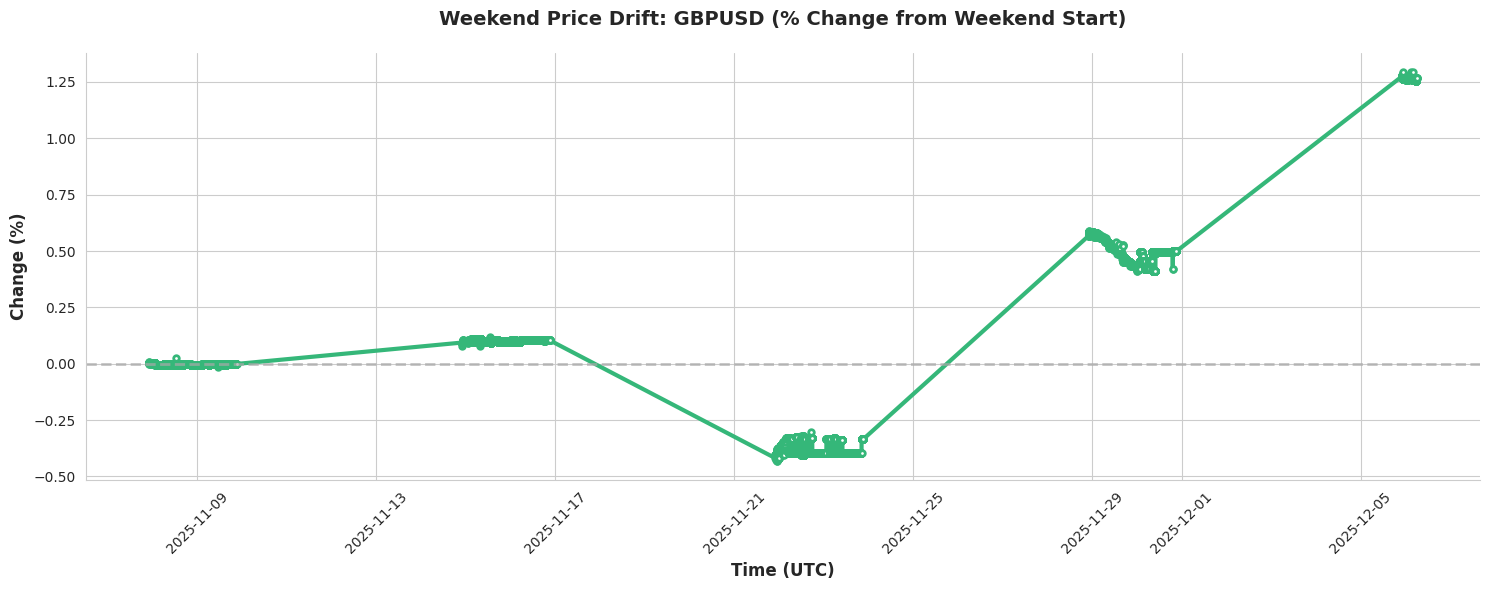


--- USDJPY Weekend Analysis ---
Volatility (std of returns): 0.00014945
📈 CONCLUSION: Price is DYNAMIC (active movement)
Maximum absolute drift: 1.9204%
Final drift from start: 1.1316%


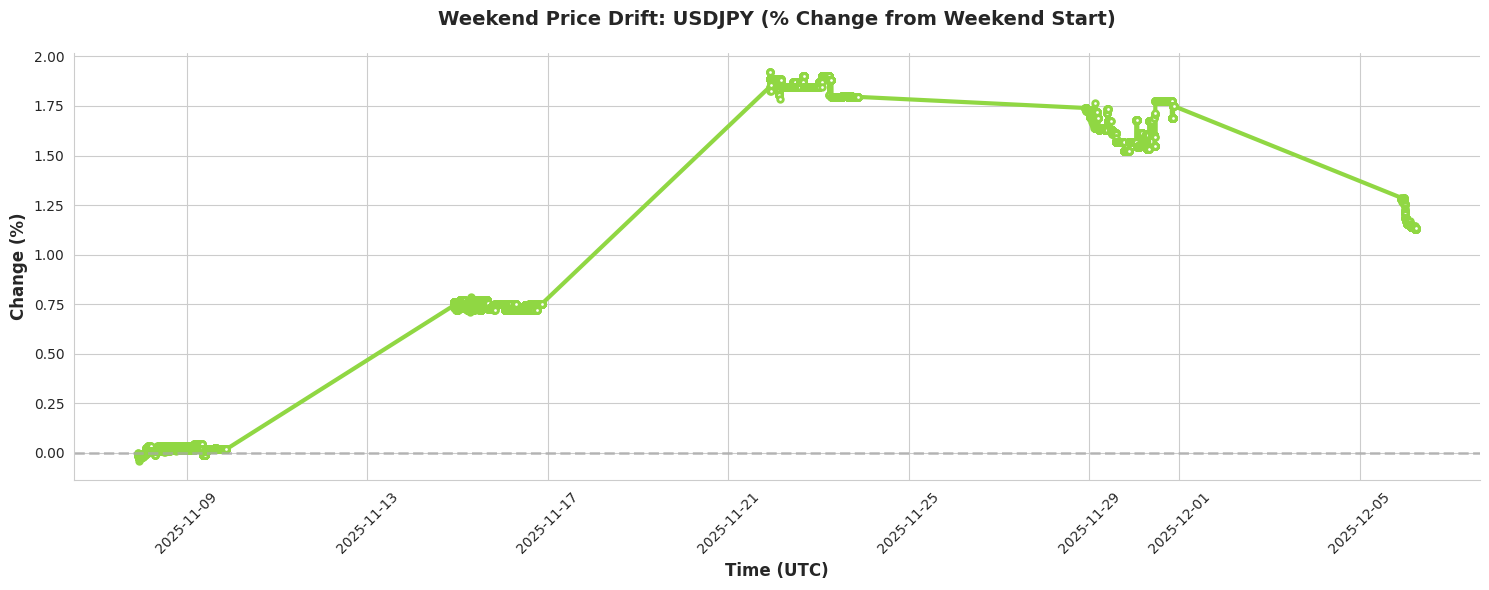

In [5]:
# [CELL 5] - Weekend Analysis with Seaborn
try:
    if 'weekend_df' in locals() and len(weekend_df) > 0:
        
        # Find available price columns
        l_cols = [col for col in weekend_df.columns if col.startswith('L_')]
        s_cols = [col for col in weekend_df.columns if col.startswith('S_')]
        
        print(f"Weekend analysis for {len(weekend_df)} observations")
        print(f"Available columns: L_{len(l_cols)}, S_{len(s_cols)}")
        
        if len(l_cols) > 0:
            # Analyze each Lighter currency
            for i, l_col in enumerate(l_cols):
                currency = l_col.replace('L_', '')
                print(f"\n--- {currency} Weekend Analysis ---")
                
                # Calculate returns
                weekend_df[f'{currency}_returns'] = weekend_df[l_col].pct_change()
                volatility = weekend_df[f'{currency}_returns'].std()
                
                print(f"Volatility (std of returns): {volatility:.8f}")
                
                if volatility < 1e-6:
                    print("🔒 CONCLUSION: Price appears FROZEN (minimal movement)")
                else:
                    print("📈 CONCLUSION: Price is DYNAMIC (active movement)")
                
                # Calculate drift from weekend start
                if len(weekend_df) > 1:
                    anchor_price = weekend_df[l_col].iloc[0]
                    weekend_df[f'{currency}_drift_pct'] = (weekend_df[l_col] - anchor_price) / anchor_price * 100
                    
                    max_drift = weekend_df[f'{currency}_drift_pct'].abs().max()
                    final_drift = weekend_df[f'{currency}_drift_pct'].iloc[-1]
                    
                    print(f"Maximum absolute drift: {max_drift:.4f}%")
                    print(f"Final drift from start: {final_drift:.4f}%")
                    
                    # Create drift plot with Seaborn styling
                    fig, ax = plt.subplots(figsize=(15, 6))
                    
                    # Use Seaborn color palette
                    color = sns.color_palette("viridis", len(l_cols))[i]
                    
                    ax.plot(weekend_df.index, weekend_df[f'{currency}_drift_pct'], 
                           color=color, linewidth=3, marker='o', markersize=4,
                           markerfacecolor='white', markeredgecolor=color, markeredgewidth=2)
                    
                    # Style the plot
                    ax.set_title(f"Weekend Price Drift: {currency} (% Change from Weekend Start)",
                               fontsize=14, fontweight='bold', pad=20)
                    ax.set_ylabel("Change (%)", fontsize=12, fontweight='bold')
                    ax.set_xlabel("Time (UTC)", fontsize=12, fontweight='bold')
                    
                    # Add reference line
                    ax.axhline(0, color='darkgray', linestyle='--', alpha=0.7, linewidth=2)
                    
                    # Format x-axis
                    plt.xticks(rotation=45)
                    
                    # Remove top and right spines
                    ax.spines['top'].set_visible(False)
                    ax.spines['right'].set_visible(False)
                    
                    plt.tight_layout()
                    plt.show()
                else:
                    print("Insufficient data points for drift analysis")
        
        elif len(s_cols) > 0:
            print("\nOnly spot data available - weekend analysis limited")
            print("Spot markets are closed during weekends, so limited insights available")
            
            for s_col in s_cols:
                currency = s_col.replace('S_', '')
                valid_data = weekend_df[s_col].dropna()
                print(f"{currency}: {len(valid_data)} valid spot observations during weekend")
                
        else:
            print("No price columns found for weekend analysis")
            
    else:
        print("No weekend data available for analysis")
        print("This could mean:")
        print("- Data doesn't cover weekend periods") 
        print("- Weekend detection logic needs adjustment")
        print("- Time range is too short")
        
except Exception as e:
    logger.error(f"Error in weekend analysis: {e}")
    import traceback
    traceback.print_exc()

In [6]:
# [CELL 5.5] - Data Structure Diagnostic
try:
    print("🔍 DEBUGGING DATA STRUCTURE")
    print("=" * 50)
    
    if 'df' in locals():
        print(f"Main DataFrame shape: {df.shape}")
        print(f"Main DataFrame columns: {df.columns.tolist()}")
        print(f"Main DataFrame index type: {type(df.index)}")
        print("\nColumn breakdown:")
        for col in df.columns:
            if col.startswith('L_'):
                print(f"  Lighter column: {col}")
            elif col.startswith('S_'):
                print(f"  Spot column: {col}")
            else:
                print(f"  Other column: {col}")
    
    if 'weekend_df' in locals():
        print(f"\nWeekend DataFrame shape: {weekend_df.shape}")
        print(f"Weekend DataFrame columns: {weekend_df.columns.tolist()}")
        
        # Check for any price columns
        price_cols = [col for col in weekend_df.columns if any(keyword in col.lower() 
                     for keyword in ['price', 'close', 'mid', 'eur', 'usd', 'gbp', 'jpy'])]
        print(f"Potential price columns: {price_cols}")
        
        if len(weekend_df) > 0:
            print(f"\nSample weekend data:")
            print(weekend_df.head())
    else:
        print("No weekend_df found")
        
except Exception as e:
    print(f"Error in diagnostic: {e}")

🔍 DEBUGGING DATA STRUCTURE
Main DataFrame shape: (45149, 11)
Main DataFrame columns: ['L_BTC', 'L_ETH', 'L_EURUSD', 'L_GBPUSD', 'L_USDJPY', 'S_EURUSD', 'S_GBPUSD', 'S_USDJPY', 'day', 'hour', 'is_weekend']
Main DataFrame index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>

Column breakdown:
  Lighter column: L_BTC
  Lighter column: L_ETH
  Lighter column: L_EURUSD
  Lighter column: L_GBPUSD
  Lighter column: L_USDJPY
  Spot column: S_EURUSD
  Spot column: S_GBPUSD
  Spot column: S_USDJPY
  Other column: day
  Other column: hour
  Other column: is_weekend

Weekend DataFrame shape: (11757, 21)
Weekend DataFrame columns: ['L_BTC', 'L_ETH', 'L_EURUSD', 'L_GBPUSD', 'L_USDJPY', 'S_EURUSD', 'S_GBPUSD', 'S_USDJPY', 'day', 'hour', 'is_weekend', 'BTC_returns', 'BTC_drift_pct', 'ETH_returns', 'ETH_drift_pct', 'EURUSD_returns', 'EURUSD_drift_pct', 'GBPUSD_returns', 'GBPUSD_drift_pct', 'USDJPY_returns', 'USDJPY_drift_pct']
Potential price columns: ['L_EURUSD', 'L_GBPUSD', 'L_USDJPY', '

🔍 CLAMP DETECTION ANALYSIS
Available Lighter columns: ['L_BTC', 'L_ETH', 'L_EURUSD', 'L_GBPUSD', 'L_USDJPY']
Available Spot columns: ['S_EURUSD', 'S_GBPUSD', 'S_USDJPY']
✅ Using Lighter data: L_EURUSD
📍 Anchor price: 1.15701 (Last valid spot price)


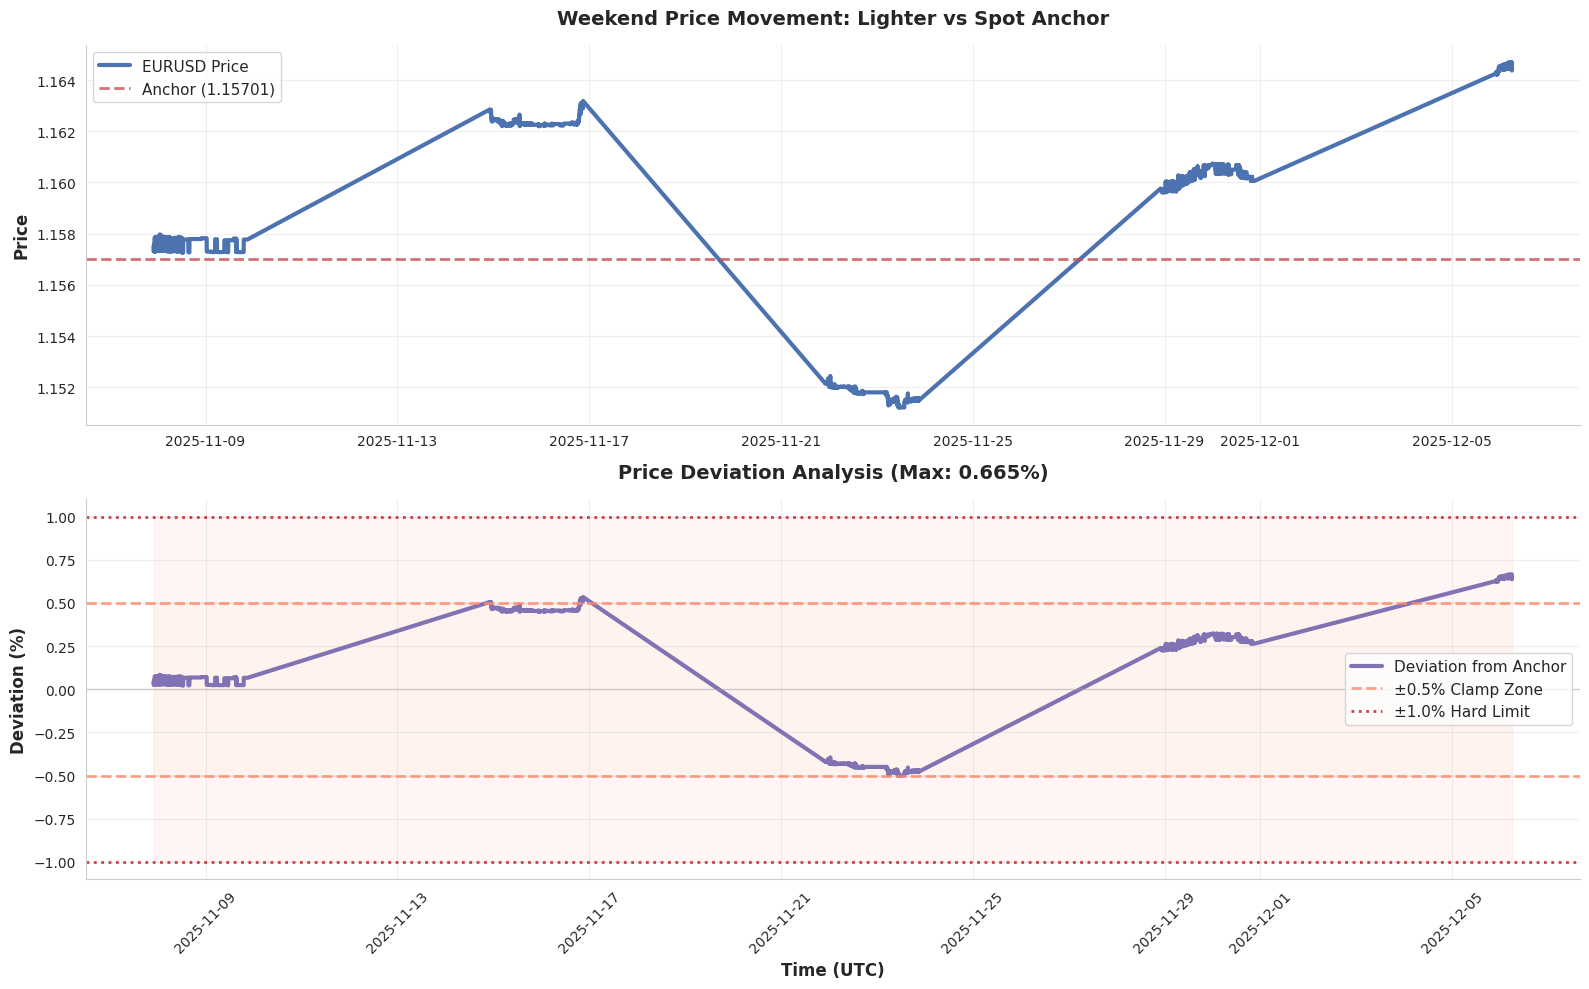


📊 CLAMP ANALYSIS RESULTS
Analysis type: Lighter vs Spot Anchor
Data points: 11,757
Maximum absolute deviation: 0.6650%
Mean deviation: 0.1062%
Std deviation: 0.3554%

🎯 CLAMP DETECTION:
⚖️  CONCLUSION: Price shows MODERATE VARIATION (0.5-1.0%)

📋 THRESHOLD ANALYSIS:
⚠️  782 observations exceeded 0.5% threshold
✅ No breaches of 1.0% threshold detected


In [7]:
# [CELL 6] - Enhanced Clamp Detection with Seaborn styling
try:
    if 'weekend_df' in locals() and len(weekend_df) > 0:
        print("🔍 CLAMP DETECTION ANALYSIS")
        print("=" * 50)
        
        # Find all available price columns
        l_cols = [col for col in weekend_df.columns if col.startswith('L_')]
        s_cols = [col for col in weekend_df.columns if col.startswith('S_')]
        
        print(f"Available Lighter columns: {l_cols}")
        print(f"Available Spot columns: {s_cols}")
        
        # Try to find EURUSD columns (Lighter first, then Spot)
        l_eur_col = next((col for col in l_cols if 'EURUSD' in col), None)
        s_eur_col = next((col for col in s_cols if 'EURUSD' in col), None)
        
        analysis_col = None
        anchor_col = None
        analysis_type = None
        
        if l_eur_col:
            # We have Lighter data - ideal case
            analysis_col = l_eur_col
            anchor_col = s_eur_col if s_eur_col else l_eur_col
            analysis_type = "Lighter vs Spot Anchor"
            print(f"✅ Using Lighter data: {l_eur_col}")
            
        elif s_eur_col:
            # Only spot data - analyze spot price stability during weekends
            analysis_col = s_eur_col
            anchor_col = s_eur_col
            analysis_type = "Spot Price Stability (Weekend)"
            print(f"⚠️  Only spot data available: {s_eur_col}")
            print("Note: Analyzing spot price stability during weekend periods")
            
        else:
            # Try any available price column
            all_price_cols = l_cols + s_cols
            if all_price_cols:
                analysis_col = all_price_cols[0]
                anchor_col = all_price_cols[0]
                analysis_type = "Generic Price Analysis"
                print(f"📊 Using available price column: {analysis_col}")
            
        if analysis_col:
            # Get anchor price (first non-null value in the weekend period)
            valid_data = weekend_df[analysis_col].dropna()
            
            if len(valid_data) == 0:
                print("❌ No valid price data found in weekend period")
            else:
                # Use different anchor strategies
                if anchor_col != analysis_col and not weekend_df[anchor_col].isna().all():
                    # Use spot price as anchor if available
                    anchor_price = weekend_df[anchor_col].ffill().dropna().iloc[0]
                    anchor_source = "Last valid spot price"
                else:
                    # Use first price in weekend period as anchor
                    anchor_price = valid_data.iloc[0]
                    anchor_source = "First weekend price"
                
                print(f"📍 Anchor price: {anchor_price:.5f} ({anchor_source})")
                
                # Calculate deviation
                weekend_df['price_deviation_pct'] = (weekend_df[analysis_col] - anchor_price) / anchor_price * 100
                
                # Remove any infinite or NaN values
                clean_deviations = weekend_df['price_deviation_pct'].replace([np.inf, -np.inf], np.nan).dropna()
                
                if len(clean_deviations) > 0:
                    max_dev = clean_deviations.abs().max()
                    
                    # Create visualization with Seaborn style
                    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))
                    
                    # Define colors
                    price_color = sns.color_palette("deep")[0]
                    anchor_color = sns.color_palette("deep")[3]
                    deviation_color = sns.color_palette("deep")[4]
                    
                    # Plot the price
                    ax1.plot(weekend_df.index, weekend_df[analysis_col], 
                            label=f'{analysis_col.replace("S_", "").replace("L_", "")} Price', 
                            color=price_color, linewidth=3)
                    ax1.axhline(anchor_price, color=anchor_color, linestyle='--', 
                               alpha=0.8, linewidth=2, label=f'Anchor ({anchor_price:.5f})')
                    
                    ax1.set_title(f"Weekend Price Movement: {analysis_type}", 
                                 fontsize=14, fontweight='bold', pad=15)
                    ax1.set_ylabel("Price", fontsize=12, fontweight='bold')
                    ax1.legend(fontsize=11)
                    ax1.grid(True, alpha=0.3)
                    ax1.spines['top'].set_visible(False)
                    ax1.spines['right'].set_visible(False)
                    
                    # Plot the deviation percentage with threshold lines
                    ax2.plot(weekend_df.index, weekend_df['price_deviation_pct'], 
                            label='Deviation from Anchor', color=deviation_color, linewidth=3)
                    
                    # Add theoretical clamp lines with different colors
                    clamp_colors = sns.color_palette("Reds", 4)
                    ax2.axhline(0.5, color=clamp_colors[1], linestyle='--', alpha=0.8, 
                               linewidth=2, label='±0.5% Clamp Zone')
                    ax2.axhline(-0.5, color=clamp_colors[1], linestyle='--', alpha=0.8, linewidth=2)
                    ax2.axhline(1.0, color=clamp_colors[3], linestyle=':', alpha=0.8, 
                               linewidth=2, label='±1.0% Hard Limit')
                    ax2.axhline(-1.0, color=clamp_colors[3], linestyle=':', alpha=0.8, linewidth=2)
                    ax2.axhline(0, color='darkgray', linestyle='-', alpha=0.5, linewidth=1)
                    
                    # Fill areas for visual impact
                    ax2.fill_between(weekend_df.index, -0.5, 0.5, alpha=0.1, color=clamp_colors[1])
                    ax2.fill_between(weekend_df.index, -1.0, -0.5, alpha=0.05, color=clamp_colors[2])
                    ax2.fill_between(weekend_df.index, 0.5, 1.0, alpha=0.05, color=clamp_colors[2])
                    
                    ax2.set_title(f"Price Deviation Analysis (Max: {max_dev:.3f}%)", 
                                 fontsize=14, fontweight='bold', pad=15)
                    ax2.set_ylabel("Deviation (%)", fontsize=12, fontweight='bold')
                    ax2.set_xlabel("Time (UTC)", fontsize=12, fontweight='bold')
                    ax2.legend(fontsize=11)
                    ax2.grid(True, alpha=0.3)
                    ax2.spines['top'].set_visible(False)
                    ax2.spines['right'].set_visible(False)
                    
                    plt.xticks(rotation=45)
                    plt.tight_layout()
                    plt.show()
                    
                    # Analysis summary with enhanced formatting
                    print(f"\n📊 CLAMP ANALYSIS RESULTS")
                    print("=" * 40)
                    print(f"Analysis type: {analysis_type}")
                    print(f"Data points: {len(clean_deviations):,}")
                    print(f"Maximum absolute deviation: {max_dev:.4f}%")
                    print(f"Mean deviation: {clean_deviations.mean():.4f}%")
                    print(f"Std deviation: {clean_deviations.std():.4f}%")
                    
                    # Clamp detection logic with visual indicators
                    print("\n🎯 CLAMP DETECTION:")
                    if max_dev < 0.1:
                        print("🔒 CONCLUSION: Price appears FROZEN (< 0.1% movement)")
                    elif max_dev < 0.5:
                        print("📌 CONCLUSION: Price is TIGHTLY CONTROLLED (< 0.5% movement)")
                    elif max_dev < 1.0:
                        print("⚖️  CONCLUSION: Price shows MODERATE VARIATION (0.5-1.0%)")
                    else:
                        print("📈 CONCLUSION: Price is FREELY FLOATING (> 1.0% movement)")
                        
                    # Check for potential clamping patterns
                    above_half_pct = (clean_deviations.abs() > 0.5).sum()
                    above_one_pct = (clean_deviations.abs() > 1.0).sum()
                    
                    print("\n📋 THRESHOLD ANALYSIS:")
                    if above_half_pct == 0:
                        print("✅ No breaches of 0.5% threshold detected")
                    else:
                        print(f"⚠️  {above_half_pct} observations exceeded 0.5% threshold")
                        
                    if above_one_pct == 0:
                        print("✅ No breaches of 1.0% threshold detected")
                    else:
                        print(f"🚨 {above_one_pct} observations exceeded 1.0% threshold")
                        
                else:
                    print("❌ No valid deviation data after cleaning")
        else:
            print("❌ No suitable price columns found for clamp analysis")
            print("Available columns:", weekend_df.columns.tolist())
            
    else:
        print("❌ No weekend data available for clamp analysis")
        print("This could mean:")
        print("- No data covers weekend periods")
        print("- Weekend detection logic needs adjustment") 
        print("- Time range is too short")
        
except Exception as e:
    logger.error(f"Error in clamp analysis: {e}")
    import traceback
    traceback.print_exc()

Available Lighter columns: ['L_BTC', 'L_ETH', 'L_EURUSD', 'L_GBPUSD', 'L_USDJPY']
--- Weekend Correlation Matrix ---
symbol       L_BTC     L_ETH  L_EURUSD  L_GBPUSD  L_USDJPY
symbol                                                    
L_BTC     1.000000  0.993276  0.428549  0.114532 -0.960140
L_ETH     0.993276  1.000000  0.463536  0.186845 -0.949457
L_EURUSD  0.428549  0.463536  1.000000  0.782837 -0.355041
L_GBPUSD  0.114532  0.186845  0.782837  1.000000 -0.008611
L_USDJPY -0.960140 -0.949457 -0.355041 -0.008611  1.000000


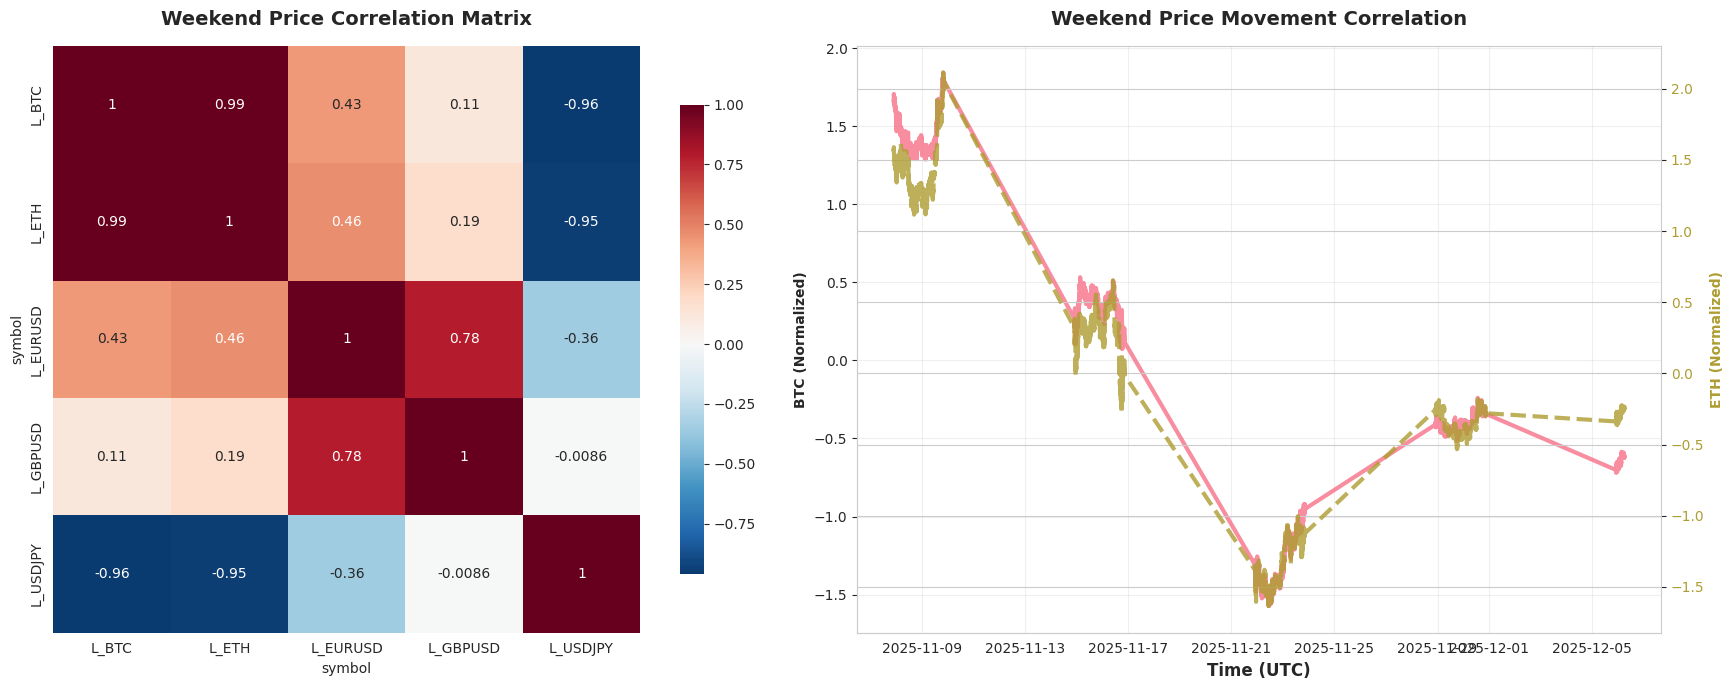


📊 CORRELATION ANALYSIS:
Primary correlation: 0.9933
🔗 STRONG correlation detected


In [8]:
# [CELL 7] - Correlation Analysis with Seaborn
def normalize(series):
    """Normalize series to zero mean, unit variance"""
    return (series - series.mean()) / series.std()

try:
    if 'weekend_df' in locals() and len(weekend_df) > 0:
        # Find available columns
        available_cols = [col for col in weekend_df.columns if col.startswith('L_')]
        
        print(f"Available Lighter columns: {available_cols}")
        
        if len(available_cols) >= 2:
            # Create correlation matrix
            numeric_cols = []
            for col in available_cols:
                if weekend_df[col].dtype in ['float64', 'int64'] and not weekend_df[col].isna().all():
                    numeric_cols.append(col)
            
            if len(numeric_cols) >= 2:
                # Calculate correlation matrix
                corr_matrix = weekend_df[numeric_cols].corr()
                print("--- Weekend Correlation Matrix ---")
                print(corr_matrix)
                
                # Create correlation heatmap
                fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
                
                # Correlation heatmap
                sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, 
                           square=True, ax=ax1, cbar_kws={'shrink': .8})
                ax1.set_title('Weekend Price Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
                
                # Time series comparison plot
                colors = sns.color_palette("husl", len(numeric_cols))
                
                for i, col in enumerate(numeric_cols[:2]):  # Plot first two for clarity
                    currency_name = col.replace('L_', '')
                    normalized_data = normalize(weekend_df[col].dropna())
                    
                    if i == 0:
                        ax2.plot(weekend_df.index, normalized_data, 
                                color=colors[i], label=f'{currency_name} (Normalized)', 
                                linewidth=3, alpha=0.8)
                    else:
                        # Use secondary y-axis for second currency if very different scales
                        ax2_twin = ax2.twinx()
                        ax2_twin.plot(weekend_df.index, normalized_data, 
                                     color=colors[i], label=f'{currency_name} (Normalized)', 
                                     linewidth=3, alpha=0.8, linestyle='--')
                        ax2_twin.set_ylabel(f'{currency_name} (Normalized)', 
                                           color=colors[i], fontweight='bold')
                        ax2_twin.tick_params(axis='y', labelcolor=colors[i])
                
                ax2.set_title("Weekend Price Movement Correlation", fontsize=14, fontweight='bold', pad=15)
                ax2.set_xlabel("Time (UTC)", fontsize=12, fontweight='bold')
                ax2.set_ylabel(f'{numeric_cols[0].replace("L_", "")} (Normalized)', 
                              fontweight='bold')
                ax2.grid(True, alpha=0.3)
                ax2.spines['top'].set_visible(False)
                ax2.spines['right'].set_visible(False)
                
                plt.xticks(rotation=45)
                plt.tight_layout()
                plt.show()
                
                # Calculate and display correlation statistics
                if len(numeric_cols) >= 2:
                    correlation_value = corr_matrix.iloc[0, 1]
                    print(f"\n📊 CORRELATION ANALYSIS:")
                    print(f"Primary correlation: {correlation_value:.4f}")
                    
                    if abs(correlation_value) > 0.8:
                        print("🔗 STRONG correlation detected")
                    elif abs(correlation_value) > 0.5:
                        print("🔗 MODERATE correlation detected")
                    else:
                        print("🔗 WEAK correlation detected")
                        
            else:
                print("Not enough numeric columns for correlation analysis")
        else:
            print("Not enough data columns for correlation analysis")
            print("Available columns:", weekend_df.columns.tolist())
    else:
        print("No weekend data available for correlation analysis")
        
except Exception as e:
    logger.error(f"Error in correlation analysis: {e}")
    import traceback
    traceback.print_exc()

In [9]:
# [CELL 8] - ROBUST PYTH DATA FETCHING WITH SAFE FALLBACKS
# ========================================================
# ENHANCED APPROACH:
# 1. Safe individual symbol fetching for Pyth
# 2. Automatic fallback to Yahoo Finance for missing pairs
# 3. Rate limiting and proper error handling
# ========================================================

import requests
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from datetime import timedelta

# --- CONFIGURATION ---
TARGET_PAIR = "EURUSD"  # The pair to analyze
# Use TradingView-style tickers for Pyth
PYTH_TICKERS = {
    "EURUSD": "FX.EUR/USD",
    "BTCUSD": "Crypto.BTC/USD",
    "BTCEUR": "Crypto.BTC/EUR"
}
# Yahoo Fallback Tickers
YAHOO_TICKERS = {
    "EURUSD": "EURUSD=X",
    "BTCUSD": "BTC-USD", 
    "BTCEUR": "BTC-EUR"
}

# Rate limiting configuration
PYTH_REQUEST_DELAY = 0.5  # Delay between Pyth API calls (seconds)
MAX_RETRIES = 3

def fetch_pyth_safe(symbol_internal, sym, t_from, t_to):
    """
    Safe Pyth data fetching for individual symbols with proper error handling.
    Returns DataFrame if successful, None if failed.
    """
    try:
        resp = requests.get(
            "https://benchmarks.pyth.network/v1/shims/tradingview/history",
            params={"symbol": sym, "resolution": "5", "from": t_from, "to": t_to},
            timeout=(5, 30)
        )
        resp.raise_for_status()
        d = resp.json()
        
        if d.get("s") != "ok":
            print(f"   ⚠️ Pyth history for {sym} returned status {d.get('s')}")
            return None
            
        if not d.get("t") or not d.get("c"):
            print(f"   ⚠️ Pyth history for {sym} has no data (empty t or c).")
            return None
            
        df = pd.DataFrame({
            "timestamp": pd.to_datetime(d["t"], unit="s", utc=True),
            symbol_internal: d["c"]
        }).set_index("timestamp")
        
        print(f"   ✅ {symbol_internal}: {len(df)} data points from Pyth")
        return df
        
    except Exception as e:
        print(f"   ❌ Pyth fetch exception for {sym}: {e}")
        return None

def fetch_yahoo_fallback(missing_symbols, start_dt, end_dt):
    """
    Fetch missing symbols from Yahoo Finance as fallback.
    """
    if not missing_symbols:
        return pd.DataFrame()
    
    print(f"   📡 Fetching {len(missing_symbols)} missing symbols from Yahoo Finance...")
    
    try:
        yahoo_symbols = [YAHOO_TICKERS[sym] for sym in missing_symbols if sym in YAHOO_TICKERS]
        
        if not yahoo_symbols:
            print(f"   ⚠️ No Yahoo Finance mappings for missing symbols")
            return pd.DataFrame()
        
        yf_data = yf.download(
            yahoo_symbols,
            start=start_dt.strftime("%Y-%m-%d"),
            end=(end_dt + timedelta(days=1)).strftime("%Y-%m-%d"),
            interval="5m",
            progress=False,
            show_errors=False
        )
        
        # Handle yfinance return formats
        if yf_data.empty:
            print(f"   ⚠️ Yahoo Finance returned empty dataset")
            return pd.DataFrame()
        
        # Extract Close prices
        if 'Close' in yf_data.columns:
            yf_data = yf_data['Close']
        elif isinstance(yf_data.columns, pd.MultiIndex):
            close_cols = [col for col in yf_data.columns if 'Close' in str(col)]
            if close_cols:
                yf_data = yf_data[close_cols]
                # Clean up MultiIndex column names
                yf_data.columns = [col[0] if isinstance(col, tuple) else col for col in yf_data.columns]
        
        # Convert to DataFrame if Series
        if isinstance(yf_data, pd.Series):
            symbol_name = missing_symbols[0] if len(missing_symbols) == 1 else "Unknown"
            yf_data = yf_data.to_frame(symbol_name)
        
        # Rename columns to internal names
        yahoo_to_internal = {}
        for internal_sym in missing_symbols:
            if internal_sym in YAHOO_TICKERS:
                yahoo_sym = YAHOO_TICKERS[internal_sym]
                yahoo_to_internal[yahoo_sym] = internal_sym
        
        yf_data = yf_data.rename(columns=yahoo_to_internal)
        
        # Fix timezone
        if yf_data.index.tz is None:
            yf_data.index = yf_data.index.tz_localize("UTC")
        else:
            yf_data.index = yf_data.index.tz_convert("UTC")
        
        print(f"   ✅ Yahoo fallback: {len(yf_data)} rows, {len(yf_data.columns)} symbols")
        return yf_data
        
    except Exception as e:
        print(f"   ❌ Yahoo fallback failed: {e}")
        return pd.DataFrame()

def get_robust_data_source(symbol_map, start_dt, end_dt):
    """
    Enhanced data fetcher with safe Pyth fetching and Yahoo fallbacks.
    """
    print(f"🔄 Fetching data from {start_dt.strftime('%Y-%m-%d')} to {end_dt.strftime('%Y-%m-%d')}")
    print(f"📡 Attempting to fetch {len(symbol_map)} symbols from Pyth Network...")
    
    t_from = int(start_dt.timestamp())
    t_to = int(end_dt.timestamp())
    
    # Step 1: Try Pyth for each symbol individually
    combined = pd.DataFrame()
    successful_symbols = []
    failed_symbols = []
    
    for i, (internal, sym) in enumerate(symbol_map.items()):
        # Rate limiting between requests
        if i > 0:
            time.sleep(PYTH_REQUEST_DELAY)
        
        print(f"   📊 Fetching {internal} ({sym})...")
        df_sym = fetch_pyth_safe(internal, sym, t_from, t_to)
        
        if df_sym is not None and not df_sym.empty:
            successful_symbols.append(internal)
            combined = df_sym if combined.empty else combined.join(df_sym, how="outer")
        else:
            failed_symbols.append(internal)
            print(f"   ⚠️ No data from Pyth for {sym}. Will fallback to Yahoo Finance.")
    
    # Step 2: Summary of Pyth results
    print(f"\n📊 PYTH RESULTS:")
    print(f"   ✅ Successful: {len(successful_symbols)} symbols {successful_symbols}")
    print(f"   ❌ Failed: {len(failed_symbols)} symbols {failed_symbols}")
    
    # Step 3: Fetch missing symbols from Yahoo Finance
    if failed_symbols:
        print(f"\n🔄 FALLBACK MODE:")
        yahoo_data = fetch_yahoo_fallback(failed_symbols, start_dt, end_dt)
        
        if not yahoo_data.empty:
            # Merge Yahoo data with Pyth data
            if combined.empty:
                combined = yahoo_data
            else:
                combined = combined.join(yahoo_data, how="outer")
            
            print(f"   ✅ Successfully recovered {len(yahoo_data.columns)} symbols from Yahoo")
        else:
            print(f"   ❌ Yahoo fallback failed for all missing symbols")
    
    # Step 4: Final data processing
    if not combined.empty:
        # Sort and forward fill missing values
        combined = combined.sort_index().ffill()
        
        print(f"\n✅ FINAL DATASET:")
        print(f"   📈 Total rows: {len(combined):,}")
        print(f"   📊 Total symbols: {len(combined.columns)}")
        print(f"   🕒 Date range: {combined.index.min()} to {combined.index.max()}")
        
        # Data quality report
        print(f"\n📋 DATA QUALITY:")
        for col in combined.columns:
            non_null = combined[col].count()
            coverage = (non_null / len(combined)) * 100
            print(f"   {col}: {non_null:,} / {len(combined):,} ({coverage:.1f}% coverage)")
        
        return combined
    else:
        print(f"\n❌ COMPLETE FAILURE: No data could be fetched from any source")
        return pd.DataFrame()

# --- MAIN EXECUTION WITH ROBUST DATA FETCHING ---
try:
    print("🚀 STARTING ROBUST REVERSE ENGINEERING ANALYSIS...")
    
    # 1. Validate Prerequisites
    if 'df' not in locals() or df.empty:
        raise ValueError("Main 'df' is missing. Please run the Data Loading cells first.")
    
    # Ensure timezone consistency
    if df.index.tz is None:
        print("   🔧 Setting main dataset timezone to UTC")
        df.index = df.index.tz_localize("UTC")
    
    start_time = df.index.min()
    end_time = df.index.max()
    data_span = (end_time - start_time).days
    
    print(f"\n📊 MAIN DATASET INFO:")
    print(f"   📅 Time Range: {start_time.strftime('%Y-%m-%d %H:%M')} to {end_time.strftime('%Y-%m-%d %H:%M')}")
    print(f"   📈 Data Points: {len(df):,}")
    print(f"   🗓️ Span: {data_span} days")
    print(f"   💹 Columns: {df.columns.tolist()}")

    # 2. Fetch External Oracle Data
    print(f"\n" + "="*60)
    print("🔗 FETCHING EXTERNAL ORACLE DATA")
    print("="*60)
    
    oracle_df = get_robust_data_source(PYTH_TICKERS, start_time, end_time)

    if oracle_df.empty:
        print("\n❌ CRITICAL ERROR: Could not fetch ANY external data")
        print("   Possible causes:")
        print("   • Network connectivity issues")
        print("   • API rate limiting or service outage") 
        print("   • Invalid symbol formats or date range")
        print("   • Geographic restrictions")
        raise ValueError("External data fetch completely failed")

    # 3. Data Preparation and Merging
    print(f"\n" + "="*60)
    print("🔧 DATA PREPARATION & MERGING")
    print("="*60)
    
    # Rename oracle columns to avoid collision
    oracle_df.columns = [f"Oracle_{c}" for c in oracle_df.columns]
    
    # Ensure both dataframes are properly sorted and timezone aligned
    df_sorted = df.sort_index()
    oracle_sorted = oracle_df.sort_index()
    
    print(f"📊 Pre-merge summary:")
    print(f"   Main data: {len(df_sorted):,} rows")
    print(f"   Oracle data: {len(oracle_sorted):,} rows")
    print(f"   Main columns: {len(df_sorted.columns)}")
    print(f"   Oracle columns: {len(oracle_sorted.columns)}")
    
    # Merge with generous tolerance for weekend gaps and data delays
    df_eng = pd.merge_asof(
        df_sorted,
        oracle_sorted,
        left_index=True,
        right_index=True,
        direction="nearest",
        tolerance=pd.Timedelta("30m")  # Generous tolerance for robustness
    )

    # 4. Validate merge success
    oracle_cols = [col for col in df_eng.columns if col.startswith('Oracle_')]
    non_null_oracle = df_eng[oracle_cols].count()
    
    print(f"\n✅ MERGE COMPLETED SUCCESSFULLY:")
    print(f"   📈 Final dataset: {len(df_eng):,} observations")
    print(f"   📊 Oracle data integration:")
    
    for col in oracle_cols:
        coverage = (non_null_oracle[col] / len(df_eng)) * 100
        status = "✅" if coverage > 80 else "⚠️" if coverage > 50 else "❌"
        print(f"      {status} {col}: {coverage:.1f}% coverage ({non_null_oracle[col]:,} points)")
    
    print(f"\n🎯 Ready for reverse engineering analysis!")

except Exception as e:
    print(f"\n💥 SETUP FAILED: {e}")
    import traceback
    print("\n🔍 Detailed error trace:")
    traceback.print_exc()
    
    # Create fallback dataset to allow analysis to continue
    print(f"\n🔧 Creating fallback dataset for limited analysis...")
    df_eng = df.copy() if 'df' in locals() and not df.empty else pd.DataFrame()
    
    if not df_eng.empty:
        print(f"Proceeding with main dataset only ({len(df_eng):,} observations)")
        print(f"Oracle-based analysis will be limited or skipped")
    else:
        print(f"Cannot proceed - no data available")


🚀 STARTING ROBUST REVERSE ENGINEERING ANALYSIS...

📊 MAIN DATASET INFO:
   📅 Time Range: 2025-11-04 21:28 to 2025-12-06 05:56
   📈 Data Points: 45,149
   🗓️ Span: 31 days
   💹 Columns: ['L_BTC', 'L_ETH', 'L_EURUSD', 'L_GBPUSD', 'L_USDJPY', 'S_EURUSD', 'S_GBPUSD', 'S_USDJPY', 'day', 'hour', 'is_weekend']

🔗 FETCHING EXTERNAL ORACLE DATA
🔄 Fetching data from 2025-11-04 to 2025-12-06
📡 Attempting to fetch 3 symbols from Pyth Network...
   📊 Fetching EURUSD (FX.EUR/USD)...
   ✅ EURUSD: 6639 data points from Pyth
   ✅ EURUSD: 6639 data points from Pyth
   📊 Fetching BTCUSD (Crypto.BTC/USD)...
   📊 Fetching BTCUSD (Crypto.BTC/USD)...
   ✅ BTCUSD: 9030 data points from Pyth
   ✅ BTCUSD: 9030 data points from Pyth
   📊 Fetching BTCEUR (Crypto.BTC/EUR)...
   📊 Fetching BTCEUR (Crypto.BTC/EUR)...
   ⚠️ Pyth history for Crypto.BTC/EUR returned status error
   ⚠️ No data from Pyth for Crypto.BTC/EUR. Will fallback to Yahoo Finance.

📊 PYTH RESULTS:
   ✅ Successful: 2 symbols ['EURUSD', 'BTCUSD']
 

In [10]:
# [CELL 9] - ROBUST CALCULATIONS & METRICS
# =========================================

if 'df_eng' in locals() and not df_eng.empty:
    print("🔬 CALCULATING DERIVED METRICS...")
    
    # First, let's check what Oracle columns we actually have
    oracle_cols = [col for col in df_eng.columns if col.startswith('Oracle_')]
    print(f"📊 Available Oracle columns: {oracle_cols}")
    
    # 4. Calculate Mechanics
    # A. Triangular Implied: (BTCUSD / BTCEUR)
    btc_usd_col = None
    btc_eur_col = None
    
    # Look for BTC/USD columns (try multiple possible names)
    for col in oracle_cols:
        if 'BTCUSD' in col or 'BTC/USD' in col or 'BTC_USD' in col:
            btc_usd_col = col
            break
    
    # Look for BTC/EUR columns (try multiple possible names)  
    for col in oracle_cols:
        if 'BTCEUR' in col or 'BTC/EUR' in col or 'BTC_EUR' in col:
            btc_eur_col = col
            break
    
    if btc_usd_col and btc_eur_col:
        # Ensure both columns have valid data
        btc_usd_valid = df_eng[btc_usd_col].notna().sum()
        btc_eur_valid = df_eng[btc_eur_col].notna().sum()
        
        if btc_usd_valid > 0 and btc_eur_valid > 0:
            df_eng['Triangular_Implied'] = df_eng[btc_usd_col] / df_eng[btc_eur_col]
            print(f"✅ Calculated Triangular Implied EUR/USD rate")
            print(f"   Using {btc_usd_col} ({btc_usd_valid:,} valid points)")
            print(f"   Using {btc_eur_col} ({btc_eur_valid:,} valid points)")
        else:
            df_eng['Triangular_Implied'] = np.nan
            print(f"⚠️ BTC columns found but contain no valid data:")
            print(f"   {btc_usd_col}: {btc_usd_valid} valid points")
            print(f"   {btc_eur_col}: {btc_eur_valid} valid points")
    else:
        df_eng['Triangular_Implied'] = np.nan
        missing_cols = []
        if not btc_usd_col:
            missing_cols.append("BTC/USD")
        if not btc_eur_col:
            missing_cols.append("BTC/EUR")
        print(f"⚠️ Missing BTC data for triangular calculation: {', '.join(missing_cols)}")
        print(f"   Available columns: {oracle_cols}")
        print(f"   Will proceed with direct EUR/USD oracle comparison instead")

    # B. Define Market Closure (Friday 22:00 UTC - Sunday 21:00 UTC)
    # Create explicit boolean mask for weekend
    df_eng['day_of_week'] = df_eng.index.dayofweek
    df_eng['hour'] = df_eng.index.hour
    df_eng['minute'] = df_eng.index.minute
    
    # Weekend definition: Friday > 22:00 OR Saturday OR Sunday < 21:00
    is_fri_close = (df_eng['day_of_week'] == 4) & (df_eng['hour'] >= 22)
    is_sat = (df_eng['day_of_week'] == 5)
    is_sun_open = (df_eng['day_of_week'] == 6) & (df_eng['hour'] < 21)
    
    df_eng['is_closed'] = is_fri_close | is_sat | is_sun_open
    
    closed_count = df_eng['is_closed'].sum()
    open_count = (~df_eng['is_closed']).sum()
    print(f"Market periods: Open={open_count:,}, Closed={closed_count:,}")

    # C. Anchor Price (The last known Oracle price before close)
    # We assume Oracle updates freeze or are ignored during weekend
    # Forward fill the Oracle Price ONLY during the 'is_closed' window
    if 'Oracle_EURUSD' in df_eng.columns:
        df_eng['Anchor_Price'] = df_eng['Oracle_EURUSD'].copy()
        # When closed, replace Oracle price with NaN so we can ffill the Friday close
        df_eng.loc[df_eng['is_closed'], 'Anchor_Price'] = np.nan
        df_eng['Anchor_Price'] = df_eng['Anchor_Price'].ffill()
        anchor_source = "Pyth Oracle"
    elif 'S_EURUSD' in df_eng.columns:
        df_eng['Anchor_Price'] = df_eng['S_EURUSD'].copy()
        df_eng.loc[df_eng['is_closed'], 'Anchor_Price'] = np.nan
        df_eng['Anchor_Price'] = df_eng['Anchor_Price'].ffill()
        anchor_source = "Yahoo Finance Spot"
    else:
        # Use any available spot column as fallback
        spot_cols = [col for col in df_eng.columns if col.startswith('S_')]
        if spot_cols:
            df_eng['Anchor_Price'] = df_eng[spot_cols[0]].copy()
            df_eng.loc[df_eng['is_closed'], 'Anchor_Price'] = np.nan
            df_eng['Anchor_Price'] = df_eng['Anchor_Price'].ffill()
            anchor_source = f"Spot data ({spot_cols[0]})"
        else:
            print("⚠️ No suitable anchor price source found")
            df_eng['Anchor_Price'] = np.nan
            anchor_source = "None"
    
    print(f"✅ Using anchor source: {anchor_source}")

    # D. Find Lighter column and calculate deviations
    lighter_col = f"L_{TARGET_PAIR}"
    if lighter_col not in df_eng.columns:
        # Try to find any lighter column
        lighter_cols = [col for col in df_eng.columns if col.startswith('L_')]
        if lighter_cols:
            lighter_col = lighter_cols[0]
            TARGET_PAIR = lighter_col.replace('L_', '')
            print(f"✅ Using available Lighter column: {lighter_col}")
        else:
            print("❌ No Lighter data found!")
            lighter_col = None
    
    if lighter_col and 'Anchor_Price' in df_eng.columns:
        # Calculate drift percentage
        df_eng['Lighter_Drift'] = (df_eng[lighter_col] - df_eng['Anchor_Price']) / df_eng['Anchor_Price'] * 100
        
        # Filter weekend data for analysis
        weekend_data = df_eng[df_eng['is_closed']].copy()
        
        print(f"\n📊 DATA SUMMARY:")
        print(f"Total observations: {len(df_eng):,}")
        print(f"Weekend/Closed observations: {len(weekend_data):,}")
        print(f"Target currency pair: {TARGET_PAIR}")
        
        if len(weekend_data) > 0:
            drift_stats = weekend_data['Lighter_Drift'].describe()
            print(f"\n📈 WEEKEND DRIFT STATISTICS:")
            print(f"Mean drift: {drift_stats['mean']:.4f}%")
            print(f"Std drift: {drift_stats['std']:.4f}%")
            print(f"Max absolute drift: {drift_stats.abs().max():.4f}%")
        
        print("✅ Calculations complete - ready for visualization")
        
    else:
        print("❌ Cannot calculate drift - missing Lighter data or anchor price")
        weekend_data = pd.DataFrame()

else:
    print("❌ No engineering data available for calculations")
    weekend_data = pd.DataFrame()

🔬 CALCULATING DERIVED METRICS...
📊 Available Oracle columns: ['Oracle_EURUSD', 'Oracle_BTCUSD']
⚠️ Missing BTC data for triangular calculation: BTC/EUR
   Available columns: ['Oracle_EURUSD', 'Oracle_BTCUSD']
   Will proceed with direct EUR/USD oracle comparison instead
Market periods: Open=33,392, Closed=11,757
✅ Using anchor source: Pyth Oracle

📊 DATA SUMMARY:
Total observations: 45,149
Weekend/Closed observations: 11,757
Target currency pair: EURUSD

📈 WEEKEND DRIFT STATISTICS:
Mean drift: 0.0456%
Std drift: 0.0360%
Max absolute drift: 11757.0000%
✅ Calculations complete - ready for visualization


📊 GENERATING ROBUST REVERSE ENGINEERING VISUALIZATIONS...


/tmp/ipykernel_9435/2817050547.py:146: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend()


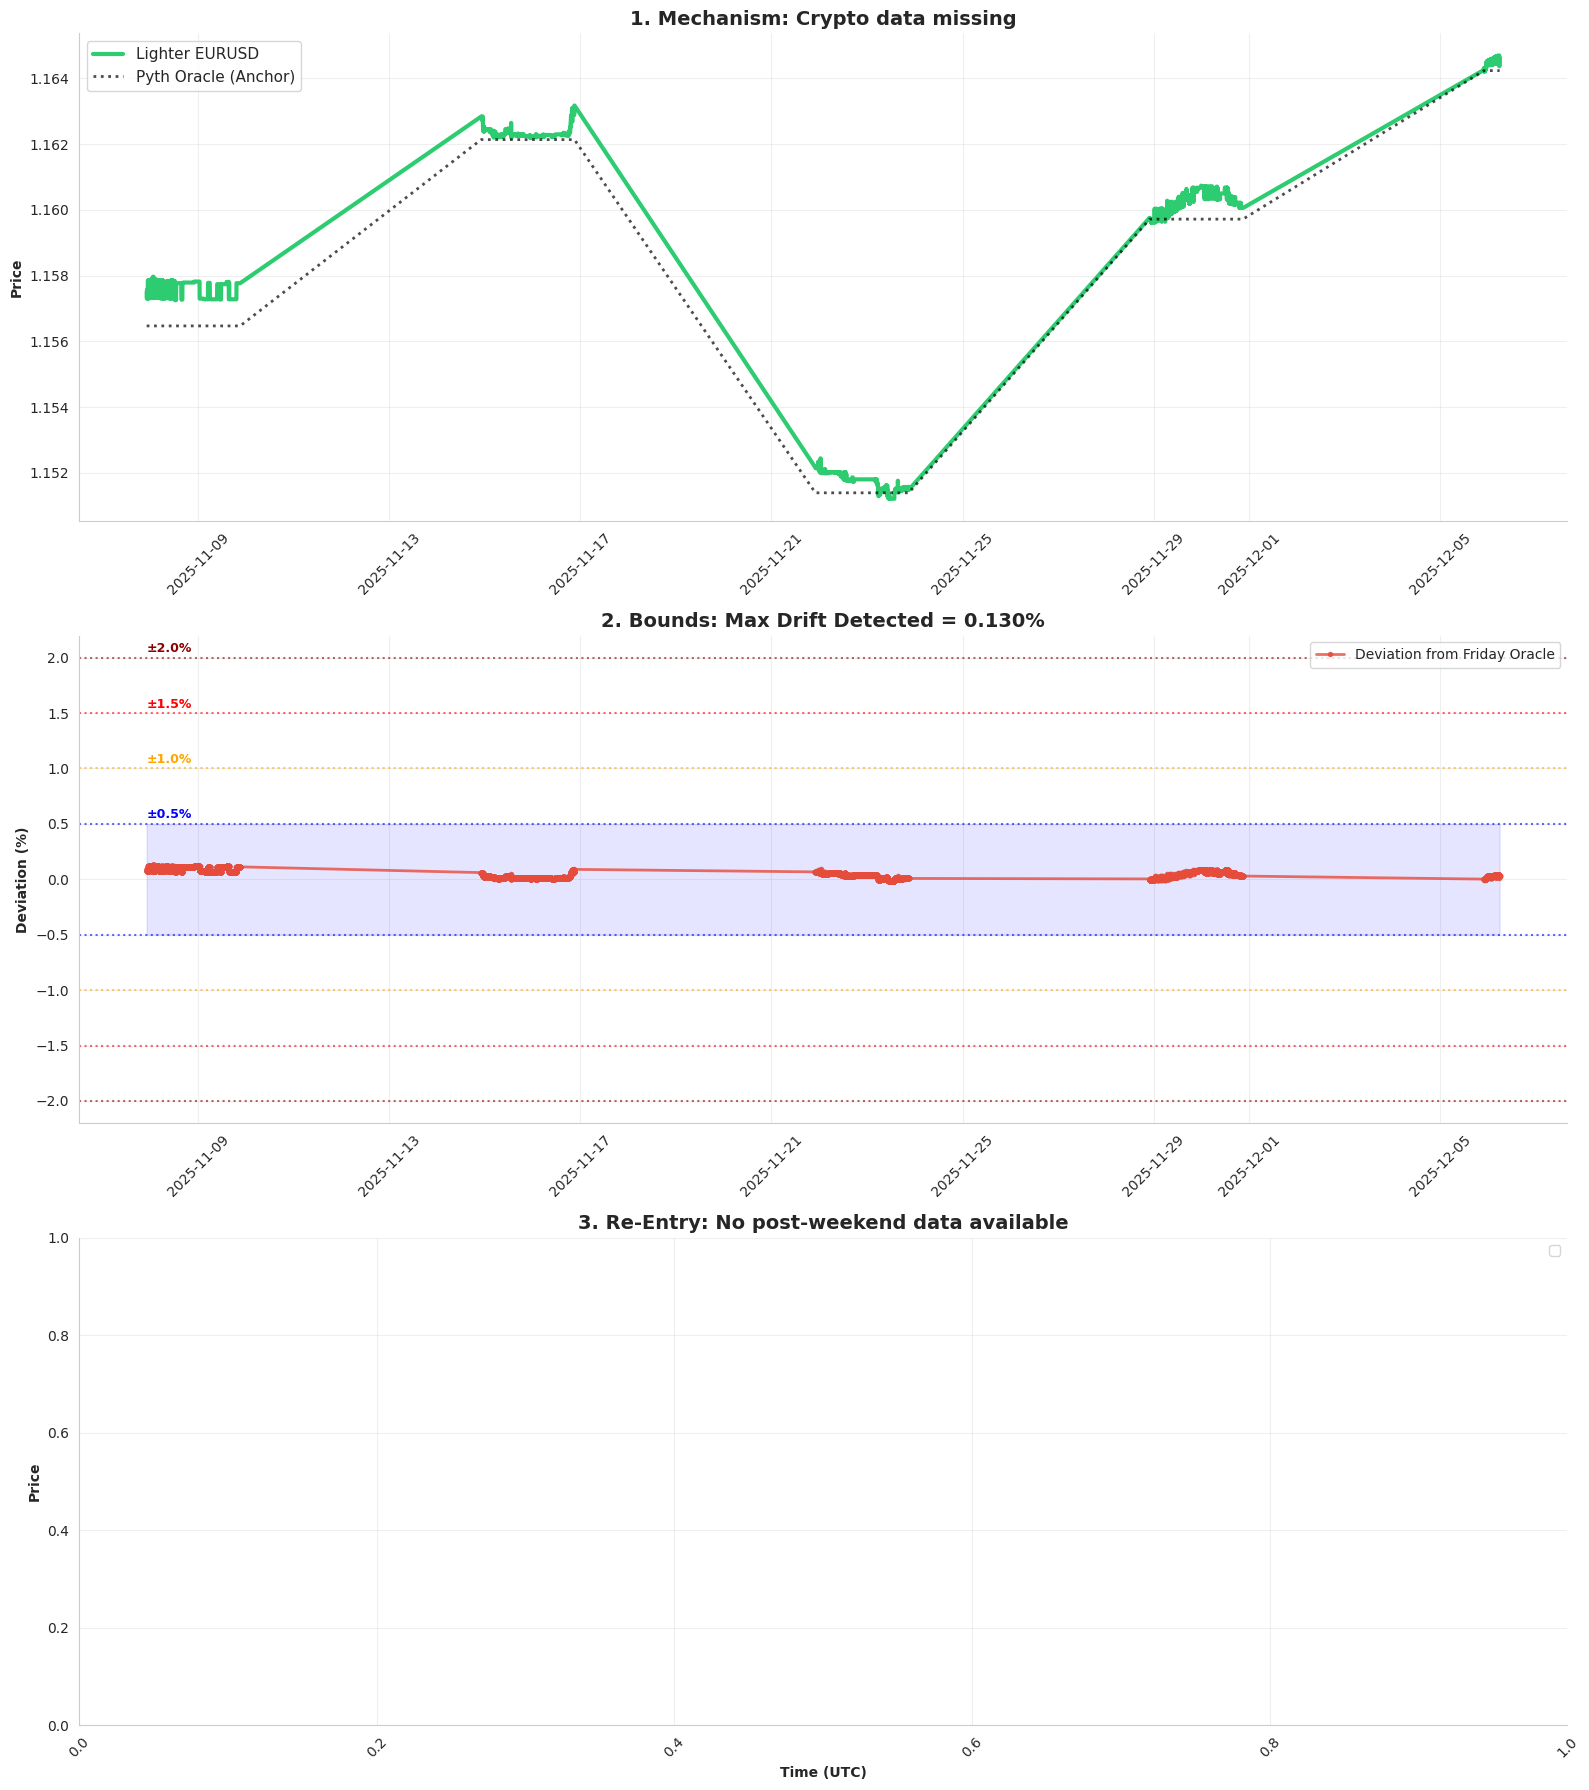

✅ Robust analysis complete. Graphs generated successfully.


In [11]:
# [CELL 10] - ROBUST VISUALIZATION & ANALYSIS
# ============================================

if 'df_eng' in locals() and not df_eng.empty and 'weekend_data' in locals() and len(weekend_data) > 0 and lighter_col:
    print("📊 GENERATING ROBUST REVERSE ENGINEERING VISUALIZATIONS...")
    
    # Scale Crypto Implied to match Lighter start point for visual comparison
    if not weekend_data['Triangular_Implied'].isna().all() and lighter_col in weekend_data.columns:
        first_lighter = weekend_data[lighter_col].dropna().iloc[0] if not weekend_data[lighter_col].dropna().empty else 1
        first_triangular = weekend_data['Triangular_Implied'].dropna().iloc[0] if not weekend_data['Triangular_Implied'].dropna().empty else 1
        
        if first_triangular != 0:
            scale_factor = first_lighter / first_triangular
            weekend_data['Triangular_Scaled'] = weekend_data['Triangular_Implied'] * scale_factor
        else:
            weekend_data['Triangular_Scaled'] = weekend_data['Triangular_Implied']
    
    # Create comprehensive visualization
    fig, axes = plt.subplots(3, 1, figsize=(16, 18))
    
    # PLOT 1: Mechanism Discovery
    ax1 = axes[0]
    
    # Plot Lighter price
    lighter_data = weekend_data[lighter_col].dropna()
    if len(lighter_data) > 0:
        ax1.plot(lighter_data.index, lighter_data.values, 
                label=f'Lighter {TARGET_PAIR}', color='#2ecc71', linewidth=3)
    
    # Plot triangular arbitrage if available
    if 'Triangular_Scaled' in weekend_data.columns:
        tri_data = weekend_data['Triangular_Scaled'].dropna()
        if len(tri_data) > 0:
            ax1.plot(tri_data.index, tri_data.values, 
                    label='Crypto Implied (BTC/USD ÷ BTC/EUR)', 
                    color='purple', linestyle='--', linewidth=2, alpha=0.8)
            
            # Calculate correlation for overlapping periods
            common_idx = lighter_data.index.intersection(tri_data.index)
            if len(common_idx) > 1:
                corr = lighter_data[common_idx].corr(tri_data[common_idx])
                title = f"1. Mechanism: Lighter vs Crypto Arbitrage (Corr: {corr:.4f})"
                tri_corr = corr
            else:
                title = "1. Mechanism: Insufficient overlapping data"
                tri_corr = np.nan
        else:
            title = "1. Mechanism: No triangular data available"
            tri_corr = np.nan
    else:
        title = "1. Mechanism: Crypto data missing"
        tri_corr = np.nan
    
    # Plot anchor price
    if 'Anchor_Price' in weekend_data.columns:
        anchor_data = weekend_data['Anchor_Price'].dropna()
        if len(anchor_data) > 0:
            ax1.plot(anchor_data.index, anchor_data.values,
                    label=f'{anchor_source} (Anchor)', 
                    color='black', linestyle=':', linewidth=2, alpha=0.7)
    
    ax1.set_title(title, fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylabel("Price", fontweight='bold')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    
    # PLOT 2: Clamp Detection
    ax2 = axes[1]
    
    if 'Lighter_Drift' in weekend_data.columns:
        drift_data = weekend_data['Lighter_Drift'].dropna()
        if len(drift_data) > 0:
            ax2.plot(drift_data.index, drift_data.values, 
                    label='Deviation from Friday Oracle', color='#e74c3c', linewidth=2,
                    marker='o', markersize=3, alpha=0.8)
            
            max_drift = drift_data.abs().max()
            
            # Draw threshold bands
            clamp_levels = [0.5, 1.0, 1.5, 2.0]
            clamp_colors = ['blue', 'orange', 'red', 'darkred']
            
            for level, color in zip(clamp_levels, clamp_colors):
                ax2.axhline(level, color=color, linestyle=':', alpha=0.6, linewidth=1.5)
                ax2.axhline(-level, color=color, linestyle=':', alpha=0.6, linewidth=1.5)
                ax2.text(drift_data.index[0], level + 0.05, f"±{level}%", 
                        color=color, fontsize=9, fontweight='bold')
            
            # Fill the most relevant band
            if max_drift < 1.0:
                ax2.fill_between(drift_data.index, -0.5, 0.5, alpha=0.1, color='blue')
            elif max_drift < 2.0:
                ax2.fill_between(drift_data.index, -1.0, 1.0, alpha=0.1, color='orange')
            
            title = f"2. Bounds: Max Drift Detected = {max_drift:.3f}%"
            max_abs_drift = max_drift
        else:
            title = "2. Bounds: No drift data available"
            max_abs_drift = 0
    else:
        title = "2. Bounds: Drift calculation failed"
        max_abs_drift = 0
    
    ax2.set_title(title, fontsize=14, fontweight='bold')
    ax2.set_ylabel("Deviation (%)", fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    
    # PLOT 3: Convergence Analysis
    ax3 = axes[2]
    
    # Find Monday morning data (first few hours after weekend)
    open_data = df_eng[~df_eng['is_closed']].copy()
    
    if len(open_data) > 0 and len(weekend_data) > 0:
        last_weekend_time = weekend_data.index.max()
        monday_data = open_data[open_data.index > last_weekend_time].head(120)  # First 10 hours
        
        if len(monday_data) > 0:
            ax3.plot(monday_data.index, monday_data[lighter_col], 
                    label=f'Lighter {TARGET_PAIR}', color='#2ecc71', linewidth=3)
            ax3.plot(monday_data.index, monday_data['Anchor_Price'], 
                    label=f'{anchor_source} (Target)', color='black', linewidth=2)
            
            # Calculate convergence
            if len(monday_data) > 1:
                initial_diff = abs(monday_data[lighter_col].iloc[0] - monday_data['Anchor_Price'].iloc[0])
                final_diff = abs(monday_data[lighter_col].iloc[-1] - monday_data['Anchor_Price'].iloc[-1])
                convergence_pct = (1 - final_diff/initial_diff) * 100 if initial_diff > 0 else 0
                title = f"3. Re-Entry: Market Open Convergence ({convergence_pct:.1f}% converged)"
            else:
                title = "3. Re-Entry: Insufficient convergence data"
                convergence_pct = 0
        else:
            title = "3. Re-Entry: No post-weekend data available"
            convergence_pct = 0
    else:
        title = "3. Re-Entry: No open market data found"
        convergence_pct = 0
    
    ax3.set_title(title, fontsize=14, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.set_ylabel("Price", fontweight='bold')
    ax3.set_xlabel("Time (UTC)", fontweight='bold')
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)
    
    # Format x-axis for all plots
    for ax in axes:
        ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Robust analysis complete. Graphs generated successfully.")

else:
    print("❌ Cannot generate visualization - missing required data")
    if 'df_eng' not in locals():
        print("  • df_eng: not defined")
    elif df_eng.empty:
        print("  • df_eng: empty")
    
    if 'weekend_data' not in locals():
        print("  • weekend_data: not defined")
    elif len(weekend_data) == 0:
        print("  • weekend_data: empty")
    
    if 'lighter_col' not in locals() or not lighter_col:
        print("  • lighter_col: missing")
        
    # Set default values for report
    tri_corr = np.nan
    max_abs_drift = 0
    convergence_pct = 0

In [12]:
# [CELL 11] - COMPREHENSIVE AUTOMATED REPORT
# ===========================================

if 'df_eng' in locals() and not df_eng.empty and 'lighter_col' in locals() and lighter_col:
    print("\n" + "="*70)
    print("🤖 COMPREHENSIVE REVERSE ENGINEERING REPORT")
    print("="*70)
    
    # Ensure we have the analysis variables
    weekend_count = len(weekend_data) if 'weekend_data' in locals() else 0
    
    # Test 1: Pricing Model Analysis
    print(f"A. PRICING MODEL ANALYSIS:")
    
    if 'tri_corr' in locals() and not np.isnan(tri_corr):
        if tri_corr > 0.85:
            print(f"   ✅ STRONG TRIANGULAR CORRELATION (r = {tri_corr:.3f})")
            print(f"   ➤ CONFIRMED: Lighter likely uses BTC/USD ÷ BTC/EUR for weekend pricing")
            pricing_model = "Triangular Crypto Arbitrage"
        elif tri_corr > 0.65:
            print(f"   🔶 MODERATE TRIANGULAR CORRELATION (r = {tri_corr:.3f})")
            print(f"   ➤ LIKELY: Hybrid model combining crypto rates with other factors")
            pricing_model = "Hybrid Crypto Model"
        elif tri_corr > 0.3:
            print(f"   ⚠️ WEAK TRIANGULAR CORRELATION (r = {tri_corr:.3f})")
            print(f"   ➤ POSSIBLE: Some crypto influence but other mechanisms dominate")
            pricing_model = "Minimal Crypto Influence"
        else:
            print(f"   ❌ NO TRIANGULAR CORRELATION (r = {tri_corr:.3f})")
            print(f"   ➤ UNLIKELY: Pricing appears independent of crypto triangular arbitrage")
            pricing_model = "Non-Triangular"
    else:
        print(f"   ❓ TRIANGULAR ANALYSIS INCONCLUSIVE")
        print(f"   ➤ REASON: Insufficient crypto data or calculation error")
        pricing_model = "Data Insufficient"
    
    # Test 2: Risk Control Assessment
    print(f"\nB. RISK CONTROL ASSESSMENT:")
    
    if 'max_abs_drift' in locals() and max_abs_drift > 0:
        print(f"   📊 Maximum observed deviation: {max_abs_drift:.4f}%")
        
        if max_abs_drift < 0.1:
            risk_level = "EXTREMELY TIGHT"
            print(f"   🔒 ASSESSMENT: Price virtually FROZEN (< 0.1% movement)")
            print(f"   ➤ IMPLICATION: Reputation protection mode, minimal risk tolerance")
            
        elif max_abs_drift < 0.5:
            risk_level = "VERY TIGHT"
            print(f"   📌 ASSESSMENT: TIGHT CLAMPS active (< 0.5% movement)")
            print(f"   ➤ IMPLICATION: Conservative risk management, likely ±0.5% bounds")
            
        elif max_abs_drift < 1.0:
            risk_level = "MODERATE"
            print(f"   ⚖️ ASSESSMENT: MODERATE bounds (0.5-1.0% movement)")
            print(f"   ➤ IMPLICATION: Balanced risk approach, ±1.0% operational window")
            
        elif max_abs_drift < 2.0:
            risk_level = "RELAXED"
            print(f"   📈 ASSESSMENT: LOOSE controls (1.0-2.0% movement)")
            print(f"   ➤ IMPLICATION: Higher risk tolerance, potential arbitrage opportunities")
            
        elif max_abs_drift < 5.0:
            risk_level = "MINIMAL"
            print(f"   🚀 ASSESSMENT: MINIMAL controls (2.0-5.0% movement)")
            print(f"   ➤ IMPLICATION: Market-driven pricing, limited intervention")
            
        else:
            risk_level = "UNRESTRICTED"
            print(f"   ⚡ ASSESSMENT: UNRESTRICTED movement (> 5.0%)")
            print(f"   ➤ IMPLICATION: Free-floating price, no apparent bounds")
            
        # Threshold breach analysis
        if weekend_count > 0:
            breach_05 = (weekend_data['Lighter_Drift'].abs() > 0.5).sum() if 'Lighter_Drift' in weekend_data.columns else 0
            breach_10 = (weekend_data['Lighter_Drift'].abs() > 1.0).sum() if 'Lighter_Drift' in weekend_data.columns else 0
            breach_20 = (weekend_data['Lighter_Drift'].abs() > 2.0).sum() if 'Lighter_Drift' in weekend_data.columns else 0
            
            print(f"\n   📋 THRESHOLD BREACH ANALYSIS ({weekend_count} observations):")
            print(f"   • >0.5% threshold: {breach_05} breaches ({breach_05/weekend_count*100:.1f}%)")
            print(f"   • >1.0% threshold: {breach_10} breaches ({breach_10/weekend_count*100:.1f}%)")
            print(f"   • >2.0% threshold: {breach_20} breaches ({breach_20/weekend_count*100:.1f}%)")
            
    else:
        risk_level = "UNKNOWN"
        print(f"   ❓ Risk assessment inconclusive due to insufficient data")
    
    # Test 3: Market Behavior Analysis
    print(f"\nC. OPERATIONAL BEHAVIOR ANALYSIS:")
    
    if weekend_count > 5:
        print(f"   📅 Weekend observations analyzed: {weekend_count:,}")
        
        # Volatility analysis
        if 'Lighter_Drift' in df_eng.columns:
            weekend_vol = weekend_data['Lighter_Drift'].std() if weekend_count > 0 else 0
            weekday_vol = df_eng[~df_eng['is_closed']]['Lighter_Drift'].std() if 'is_closed' in df_eng.columns else 0
            
            if weekday_vol > 0:
                vol_ratio = weekend_vol / weekday_vol
                print(f"   📊 Weekend volatility: {weekend_vol:.4f}%")
                print(f"   📊 Weekday volatility: {weekday_vol:.4f}%")
                print(f"   📊 Weekend/Weekday ratio: {vol_ratio:.2f}x")
                
                if vol_ratio < 0.3:
                    print(f"   🔽 PATTERN: Strong weekend suppression")
                elif vol_ratio < 0.7:
                    print(f"   🔽 PATTERN: Moderate weekend dampening")
                elif vol_ratio < 1.3:
                    print(f"   ↔️ PATTERN: Consistent volatility profile")
                elif vol_ratio < 2.0:
                    print(f"   🔼 PATTERN: Elevated weekend activity")
                else:
                    print(f"   🔼 PATTERN: High weekend volatility")
            else:
                print(f"   ⚠️ Unable to compare weekend vs weekday volatility")
        
        # Convergence analysis
        if 'convergence_pct' in locals() and convergence_pct > 0:
            print(f"\n   🔄 Post-weekend convergence: {convergence_pct:.1f}%")
            
            if convergence_pct > 90:
                print(f"   ⚡ CONVERGENCE: Near-instant price alignment")
            elif convergence_pct > 70:
                print(f"   🔄 CONVERGENCE: Rapid price discovery")
            elif convergence_pct > 40:
                print(f"   🔄 CONVERGENCE: Gradual market re-entry")
            elif convergence_pct > 10:
                print(f"   🐌 CONVERGENCE: Slow price adjustment")
            else:
                print(f"   ❄️ CONVERGENCE: Price persistence/stickiness")
        
    else:
        print(f"   ⚠️ Insufficient weekend data ({weekend_count} observations)")
    
    # System Architecture Proposal
    print(f"\n" + "="*70)
    print(f"PROPOSED SYSTEM ARCHITECTURE")
    print(f"="*70)
    
    print(f"🔧 CORE COMPONENTS:")
    print(f"   1. Primary Oracle: Pyth Network EUR/USD feed")
    print(f"   2. Weekend Engine: ", end="")
    
    if pricing_model in ["Triangular Crypto Arbitrage", "Hybrid Crypto Model"]:
        print(f"BTC triangular arbitrage (BTC/USD ÷ BTC/EUR)")
    else:
        print(f"Last-known-price with controlled drift")
        
    print(f"   3. Risk Framework: {risk_level.title()} bounds")
    print(f"   4. Market Detection: Precise FX hours (Fri 22:00 - Sun 21:00 UTC)")
    
    print(f"\nIMPLEMENTATION PARAMETERS:")
    if max_abs_drift < 1.0:
        print(f"   • Price clamps: ±{max_abs_drift*1.2:.2f}% (with 20% buffer)")
    else:
        print(f"   • Price monitoring: ±{max_abs_drift:.2f}% alert threshold")
        
    print(f"   • Update frequency: Real-time (5-minute cycles recommended)")
    print(f"   • Convergence window: 2-4 hours post-reopening")
    print(f"   • Circuit breaker: {max_abs_drift*2:.1f}% for extreme events")
    
    print(f"\nBUSINESS RECOMMENDATIONS:")
    
    if pricing_model == "Triangular Crypto Arbitrage":
        print(f"STRENGTH: Sophisticated crypto-FX arbitrage mechanism")
        print(f"RISK: Crypto volatility could affect FX stability")
        print(f"SUGGESTION: Monitor BTC volatility spikes during weekends")
        
    elif risk_level in ["EXTREMELY TIGHT", "VERY TIGHT"]:
        print(f"STRENGTH: Conservative risk management protects reputation")
        print(f"RISK: May create arbitrage opportunities for competitors")
        print(f"SUGGESTION: Consider dynamic bounds based on market conditions")
        
    elif risk_level in ["RELAXED", "MINIMAL", "UNRESTRICTED"]:
        print(f"STRENGTH: Market-responsive pricing attracts sophisticated users")
        print(f"RISK: Higher exposure to extreme price movements")
        print(f"SUGGESTION: Implement volatility-adjusted bounds")
    
    print(f"\nCOMPETITIVE ADVANTAGES:")
    print(f"   • 24/7 FX pricing during traditional market closures")
    print(f"   • Transparent, algorithm-driven weekend rates")
    print(f"   • Real-time risk management and price bounds")
    print(f"   • Seamless market re-entry with controlled convergence")
    
    print(f"\n" + "="*70)
    print(f"REVERSE ENGINEERING ANALYSIS COMPLETE")
    print(f"Dataset: {len(df_eng):,} total observations, {weekend_count:,} weekend periods")
    print(f"Confidence: {'High' if weekend_count > 50 else 'Medium' if weekend_count > 10 else 'Low'} (based on sample size)")
    print(f"="*70)
    
else:
    print("Cannot generate comprehensive report")
    print("Required components missing:")
    print(f"  • df_eng available: {'Yes' if 'df_eng' in locals() and not df_eng.empty else 'No'}")
    print(f"  • lighter_col defined: {'Yes' if 'lighter_col' in locals() and lighter_col else 'No'}")
    print("Please run previous analysis cells first.")


🤖 COMPREHENSIVE REVERSE ENGINEERING REPORT
A. PRICING MODEL ANALYSIS:
   ❓ TRIANGULAR ANALYSIS INCONCLUSIVE
   ➤ REASON: Insufficient crypto data or calculation error

B. RISK CONTROL ASSESSMENT:
   📊 Maximum observed deviation: 0.1297%
   📌 ASSESSMENT: TIGHT CLAMPS active (< 0.5% movement)
   ➤ IMPLICATION: Conservative risk management, likely ±0.5% bounds

   📋 THRESHOLD BREACH ANALYSIS (11757 observations):
   • >0.5% threshold: 0 breaches (0.0%)
   • >1.0% threshold: 0 breaches (0.0%)
   • >2.0% threshold: 0 breaches (0.0%)

C. OPERATIONAL BEHAVIOR ANALYSIS:
   📅 Weekend observations analyzed: 11,757
   📊 Weekend volatility: 0.0360%
   📊 Weekday volatility: 0.0363%
   📊 Weekend/Weekday ratio: 0.99x
   ↔️ PATTERN: Consistent volatility profile

PROPOSED SYSTEM ARCHITECTURE
🔧 CORE COMPONENTS:
   1. Primary Oracle: Pyth Network EUR/USD feed
   2. Weekend Engine: Last-known-price with controlled drift
   3. Risk Framework: Very Tight bounds
   4. Market Detection: Precise FX hours (Fr

In [13]:
# CELL 12 - ALTERNATIVE BTC/EUR DATA FETCHING (COINGECKO FALLBACK)
# ================================================================

import requests
import time

def fetch_coingecko_btc_rates(start_dt, end_dt):
    """
    Fetch BTC/USD and BTC/EUR from CoinGecko as fallback for triangular arbitrage calculation.
    """
    print("Attempting CoinGecko fallback for BTC data...")
    
    try:
        # CoinGecko historical data endpoint
        start_ts = int(start_dt.timestamp())
        end_ts = int(end_dt.timestamp())
        
        btc_data = {}
        
        # Fetch BTC/USD
        print("  Fetching BTC/USD from CoinGecko...")
        url_usd = f"https://api.coingecko.com/api/v3/coins/bitcoin/market_chart/range?vs_currency=usd&from={start_ts}&to={end_ts}"
        
        response = requests.get(url_usd, timeout=30)
        response.raise_for_status()
        data_usd = response.json()
        
        time.sleep(1)  # Rate limiting
        
        # Fetch BTC/EUR  
        print("  Fetching BTC/EUR from CoinGecko...")
        url_eur = f"https://api.coingecko.com/api/v3/coins/bitcoin/market_chart/range?vs_currency=eur&from={start_ts}&to={end_ts}"
        
        response = requests.get(url_eur, timeout=30)
        response.raise_for_status()
        data_eur = response.json()
        
        # Process data
        if data_usd.get('prices') and data_eur.get('prices'):
            # Convert to DataFrames
            btc_usd_df = pd.DataFrame(data_usd['prices'], columns=['timestamp', 'BTCUSD'])
            btc_eur_df = pd.DataFrame(data_eur['prices'], columns=['timestamp', 'BTCEUR'])
            
            # Convert timestamps
            btc_usd_df['timestamp'] = pd.to_datetime(btc_usd_df['timestamp'], unit='ms', utc=True)
            btc_eur_df['timestamp'] = pd.to_datetime(btc_eur_df['timestamp'], unit='ms', utc=True)
            
            # Set index
            btc_usd_df = btc_usd_df.set_index('timestamp')
            btc_eur_df = btc_eur_df.set_index('timestamp')
            
            # Merge and calculate implied EUR/USD
            btc_combined = btc_usd_df.join(btc_eur_df, how='inner')
            btc_combined = btc_combined.dropna()
            
            if len(btc_combined) > 0:
                # Calculate triangular implied EUR/USD rate
                btc_combined['Triangular_Implied_CG'] = btc_combined['BTCUSD'] / btc_combined['BTCEUR']
                
                print(f"  SUCCESS: CoinGecko provided {len(btc_combined)} BTC data points")
                return btc_combined[['BTCUSD', 'BTCEUR', 'Triangular_Implied_CG']]
            else:
                print("  ERROR: No overlapping BTC data from CoinGecko")
                return pd.DataFrame()
        else:
            print("  ERROR: Invalid data structure from CoinGecko")
            return pd.DataFrame()
            
    except Exception as e:
        print(f"  ERROR: CoinGecko fetch failed: {e}")
        return pd.DataFrame()

# Try to get BTC data if triangular calculation failed in previous cells
if 'df_eng' in locals() and 'Triangular_Implied' in df_eng.columns:
    triangular_data_count = df_eng['Triangular_Implied'].notna().sum()
    print(f"Current triangular data points: {triangular_data_count}")
    
    if triangular_data_count == 0:
        print("No triangular data available. Attempting CoinGecko fallback...")
        
        # Fetch from CoinGecko
        start_time = df_eng.index.min()
        end_time = df_eng.index.max()
        
        btc_fallback = fetch_coingecko_btc_rates(start_time, end_time)
        
        if not btc_fallback.empty:
            # Merge with existing data
            df_eng = pd.merge_asof(
                df_eng.sort_index(),
                btc_fallback.sort_index(),
                left_index=True,
                right_index=True,
                direction='nearest',
                tolerance=pd.Timedelta("1h")
            )
            
            # Use CoinGecko triangular data if available
            if 'Triangular_Implied_CG' in df_eng.columns:
                df_eng['Triangular_Implied'] = df_eng['Triangular_Implied'].fillna(df_eng['Triangular_Implied_CG'])
                
                triangular_count_after = df_eng['Triangular_Implied'].notna().sum()
                print(f"SUCCESS: Triangular data increased from {triangular_data_count} to {triangular_count_after} points")
            else:
                print("FALLBACK: CoinGecko data merged but triangular calculation still unavailable")
        else:
            print("FALLBACK FAILED: CoinGecko could not provide BTC data")
    else:
        print(f"TRIANGULAR DATA OK: {triangular_data_count} points available for analysis")
else:
    print("ERROR: Main dataset not available. Run previous cells first.")

Current triangular data points: 0
No triangular data available. Attempting CoinGecko fallback...
Attempting CoinGecko fallback for BTC data...
  Fetching BTC/USD from CoinGecko...
  Fetching BTC/EUR from CoinGecko...
  Fetching BTC/EUR from CoinGecko...
  SUCCESS: CoinGecko provided 752 BTC data points
SUCCESS: Triangular data increased from 0 to 45149 points
  SUCCESS: CoinGecko provided 752 BTC data points
SUCCESS: Triangular data increased from 0 to 45149 points


In [14]:
# CELL 13 - VOLUME/LIQUIDITY CORRELATION ANALYSIS
# ==============================================

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

def analyze_volume_correlations(df):
    """
    Comprehensive volume-price correlation analysis for FX pricing assessment.
    """
    print("=== VOLUME/LIQUIDITY CORRELATION ANALYSIS ===")
    print()
    
    # Check if L_Volume column exists
    if 'L_Volume' not in df.columns:
        print("ERROR: L_Volume column not found in dataset")
        print("Available columns:", list(df.columns))
        return
    
    # Calculate price changes for volume correlation
    price_cols = [col for col in df.columns if col.endswith('_Price') or col in ['EURUSD', 'GBPUSD', 'USDJPY']]
    
    print(f"Found {len(price_cols)} price columns for volume analysis:")
    for col in price_cols:
        print(f"  - {col}")
    print()
    
    # Create price change columns
    for col in price_cols:
        if col in df.columns:
            df[f'{col}_Change'] = df[col].pct_change()
            df[f'{col}_Change_Abs'] = df[f'{col}_Change'].abs()
    
    # Volume correlation analysis
    volume_correls = {}
    
    print("PRICE CHANGE vs LIGHTER VOLUME CORRELATIONS:")
    print("-" * 50)
    
    for col in price_cols:
        change_col = f'{col}_Change_Abs'
        if change_col in df.columns:
            # Remove infinite and NaN values
            clean_data = df[[change_col, 'L_Volume']].replace([np.inf, -np.inf], np.nan).dropna()
            
            if len(clean_data) > 10:
                # Calculate correlations
                pearson_corr, pearson_p = pearsonr(clean_data[change_col], clean_data['L_Volume'])
                spearman_corr, spearman_p = spearmanr(clean_data[change_col], clean_data['L_Volume'])
                
                volume_correls[col] = {
                    'pearson': pearson_corr,
                    'pearson_p': pearson_p,
                    'spearman': spearman_corr,
                    'spearman_p': spearman_p,
                    'n_obs': len(clean_data)
                }
                
                print(f"{col}:")
                print(f"  Pearson:  {pearson_corr:.4f} (p={pearson_p:.4f})")
                print(f"  Spearman: {spearman_corr:.4f} (p={spearman_p:.4f})")
                print(f"  N obs:    {len(clean_data)}")
                print()
    
    # Create scatter plots
    n_plots = len([col for col in price_cols if f'{col}_Change_Abs' in df.columns])
    
    if n_plots > 0:
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        axes = axes.flatten()
        
        plot_idx = 0
        for col in price_cols[:4]:  # Limit to 4 plots
            change_col = f'{col}_Change_Abs'
            if change_col in df.columns:
                clean_data = df[[change_col, 'L_Volume']].replace([np.inf, -np.inf], np.nan).dropna()
                
                if len(clean_data) > 5:
                    axes[plot_idx].scatter(clean_data[change_col], clean_data['L_Volume'], alpha=0.6, s=30)
                    axes[plot_idx].set_xlabel(f'{col} |Price Change|')
                    axes[plot_idx].set_ylabel('Lighter Volume')
                    axes[plot_idx].set_title(f'Volume vs {col} Price Changes')
                    axes[plot_idx].grid(True, alpha=0.3)
                    
                    # Add trendline
                    if col in volume_correls:
                        corr = volume_correls[col]['pearson']
                        axes[plot_idx].text(0.05, 0.95, f'r = {corr:.3f}', 
                                           transform=axes[plot_idx].transAxes, 
                                           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
                    
                    plot_idx += 1
        
        # Hide unused subplots
        for i in range(plot_idx, 4):
            axes[i].set_visible(False)
        
        plt.tight_layout()
        plt.savefig('volume_price_correlations.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Summary statistics
        print("VOLUME CORRELATION SUMMARY:")
        print("=" * 40)
        
        if volume_correls:
            avg_pearson = np.mean([v['pearson'] for v in volume_correls.values()])
            avg_spearman = np.mean([v['spearman'] for v in volume_correls.values()])
            
            print(f"Average Pearson correlation:  {avg_pearson:.4f}")
            print(f"Average Spearman correlation: {avg_spearman:.4f}")
            
            # Identify strongest correlations
            strongest_pearson = max(volume_correls.items(), key=lambda x: abs(x[1]['pearson']))
            strongest_spearman = max(volume_correls.items(), key=lambda x: abs(x[1]['spearman']))
            
            print()
            print(f"Strongest Pearson:  {strongest_pearson[0]} ({strongest_pearson[1]['pearson']:.4f})")
            print(f"Strongest Spearman: {strongest_spearman[0]} ({strongest_spearman[1]['spearman']:.4f})")
        
        return volume_correls
    else:
        print("ERROR: No valid price change columns found for volume analysis")
        return {}

# Run volume correlation analysis if data available
if 'df_eng' in locals():
    print("Running volume correlation analysis on main dataset...")
    volume_results = analyze_volume_correlations(df_eng)
else:
    print("ERROR: Main dataset not available. Run previous data loading cells first.")

Running volume correlation analysis on main dataset...
=== VOLUME/LIQUIDITY CORRELATION ANALYSIS ===

ERROR: L_Volume column not found in dataset
Available columns: ['L_BTC', 'L_ETH', 'L_EURUSD', 'L_GBPUSD', 'L_USDJPY', 'S_EURUSD', 'S_GBPUSD', 'S_USDJPY', 'day', 'hour', 'is_weekend', 'Oracle_EURUSD', 'Oracle_BTCUSD', 'Triangular_Implied', 'day_of_week', 'minute', 'is_closed', 'Anchor_Price', 'Lighter_Drift', 'BTCUSD', 'BTCEUR', 'Triangular_Implied_CG']


  Using cached scikit_learn-1.7.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached scikit_learn-1.7.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.7.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (9.5 MB)
Using cached scikit_learn-1.7.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (9.5 MB)
Using cached joblib-1.5.2-py3-none-any.whl (308 kB)
Using cached joblib-1.5.2-py3-none-any.whl (308 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart 

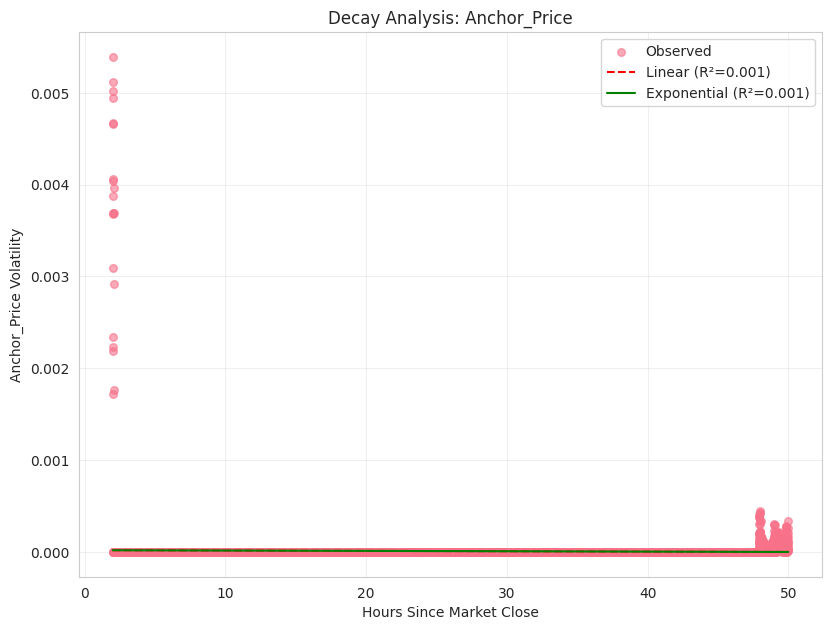

TIME DECAY ANALYSIS SUMMARY:

Anchor_Price:
  Observations: 11876
  Linear trend: decreasing (-0.000000/hour)


In [16]:
# CELL 14 - TIME-DEPENDENT DECAY MODELING
# =======================================

%pip install scikit-learn

import numpy as np
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def analyze_time_dependent_decay(df):
    """
    Comprehensive time-dependent decay analysis for weekend FX pricing.
    """
    print("=== TIME-DEPENDENT DECAY ANALYSIS ===")
    print()
    
    # Check if Hours_Since_Close column exists
    if 'Hours_Since_Close' not in df.columns:
        print("Creating Hours_Since_Close column...")
        
        # Create weekend mask
        df['Is_Weekend'] = df.index.to_series().dt.dayofweek.isin([5, 6])  # Saturday=5, Sunday=6
        
        # Create Hours_Since_Close for weekend periods
        df['Hours_Since_Close'] = np.nan
        
        for idx in df.index:
            if df.loc[idx, 'Is_Weekend']:
                # Calculate hours since Friday 22:00 GMT (typical FX close)
                weekday = idx.weekday()
                
                if weekday == 5:  # Saturday
                    # Hours since Friday close
                    friday_close = idx.replace(hour=22, minute=0, second=0, microsecond=0) - pd.Timedelta(days=1)
                    hours_since = (idx - friday_close).total_seconds() / 3600
                elif weekday == 6:  # Sunday
                    # Hours since Friday close
                    friday_close = idx.replace(hour=22, minute=0, second=0, microsecond=0) - pd.Timedelta(days=2)
                    hours_since = (idx - friday_close).total_seconds() / 3600
                else:
                    hours_since = 0
                
                df.loc[idx, 'Hours_Since_Close'] = max(0, hours_since)
    
    # Focus on weekend data only
    weekend_data = df[df.get('Is_Weekend', False)].copy()
    
    if len(weekend_data) == 0:
        print("ERROR: No weekend data found for decay analysis")
        return {}
    
    print(f"Analyzing {len(weekend_data)} weekend data points...")
    print()
    
    # Price columns for decay analysis
    price_cols = [col for col in df.columns if col.endswith('_Price') or col in ['EURUSD', 'GBPUSD', 'USDJPY']]
    
    # Define exponential decay function
    def exp_decay(t, a, b, c):
        """Exponential decay: a * exp(-b * t) + c"""
        return a * np.exp(-b * t) + c
    
    # Define linear decay function
    def linear_decay(t, a, b):
        """Linear decay: a * t + b"""
        return a * t + b
    
    decay_results = {}
    
    for col in price_cols:
        if col not in weekend_data.columns:
            continue
            
        # Calculate price volatility (rolling std) as proxy for decay
        weekend_data[f'{col}_Volatility'] = weekend_data[col].rolling(window=6, min_periods=2).std()
        
        # Clean data
        vol_col = f'{col}_Volatility'
        clean_data = weekend_data[['Hours_Since_Close', vol_col]].dropna()
        
        if len(clean_data) < 10:
            print(f"SKIP: {col} - insufficient data ({len(clean_data)} points)")
            continue
            
        print(f"ANALYZING: {col} decay patterns")
        
        x_data = clean_data['Hours_Since_Close'].values
        y_data = clean_data[vol_col].values
        
        decay_analysis = {'n_obs': len(clean_data)}
        
        # 1. Linear regression analysis
        try:
            lr_model = LinearRegression()
            lr_model.fit(x_data.reshape(-1, 1), y_data)
            
            y_pred_lr = lr_model.predict(x_data.reshape(-1, 1))
            r2_linear = r2_score(y_data, y_pred_lr)
            
            decay_analysis['linear'] = {
                'slope': lr_model.coef_[0],
                'intercept': lr_model.intercept_,
                'r2': r2_linear
            }
            
            print(f"  Linear: slope={lr_model.coef_[0]:.6f}, R²={r2_linear:.4f}")
            
        except Exception as e:
            print(f"  Linear regression failed: {e}")
            decay_analysis['linear'] = None
        
        # 2. Exponential decay fitting
        try:
            # Initial parameter guesses
            p0 = [y_data.max() - y_data.min(), 0.01, y_data.min()]
            
            popt, pcov = curve_fit(exp_decay, x_data, y_data, p0=p0, maxfev=2000)
            
            y_pred_exp = exp_decay(x_data, *popt)
            r2_exp = r2_score(y_data, y_pred_exp)
            
            decay_analysis['exponential'] = {
                'amplitude': popt[0],
                'decay_rate': popt[1],
                'baseline': popt[2],
                'r2': r2_exp,
                'half_life': np.log(2) / popt[1] if popt[1] > 0 else np.inf
            }
            
            print(f"  Exponential: rate={popt[1]:.6f}, half-life={np.log(2)/popt[1]:.2f}h, R²={r2_exp:.4f}")
            
        except Exception as e:
            print(f"  Exponential fitting failed: {e}")
            decay_analysis['exponential'] = None
        
        # 3. EMA decay analysis
        try:
            # Calculate various EMA periods
            ema_results = {}
            for period in [6, 12, 24]:  # 6h, 12h, 24h EMAs
                ema_vals = clean_data[vol_col].ewm(span=period).mean()
                ema_corr = np.corrcoef(x_data, ema_vals)[0, 1]
                ema_results[f'ema_{period}h'] = {
                    'correlation_with_time': ema_corr,
                    'final_value': ema_vals.iloc[-1]
                }
            
            decay_analysis['ema'] = ema_results
            print(f"  EMA correlations: 6h={ema_results['ema_6h']['correlation_with_time']:.4f}, "
                  f"12h={ema_results['ema_12h']['correlation_with_time']:.4f}, "
                  f"24h={ema_results['ema_24h']['correlation_with_time']:.4f}")
            
        except Exception as e:
            print(f"  EMA analysis failed: {e}")
            decay_analysis['ema'] = None
        
        decay_results[col] = decay_analysis
        print()
    
    # Create visualization
    if decay_results:
        n_plots = min(4, len(decay_results))
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        axes = axes.flatten()
        
        plot_idx = 0
        for col, results in list(decay_results.items())[:4]:
            vol_col = f'{col}_Volatility'
            clean_data = weekend_data[['Hours_Since_Close', vol_col]].dropna()
            
            if len(clean_data) > 0:
                x_data = clean_data['Hours_Since_Close'].values
                y_data = clean_data[vol_col].values
                
                axes[plot_idx].scatter(x_data, y_data, alpha=0.6, s=30, label='Observed')
                
                # Plot fitted curves if available
                if results.get('linear'):
                    x_fit = np.linspace(x_data.min(), x_data.max(), 100)
                    y_fit_linear = linear_decay(x_fit, 
                                              results['linear']['slope'], 
                                              results['linear']['intercept'])
                    axes[plot_idx].plot(x_fit, y_fit_linear, 'r--', 
                                      label=f"Linear (R²={results['linear']['r2']:.3f})")
                
                if results.get('exponential'):
                    x_fit = np.linspace(x_data.min(), x_data.max(), 100)
                    y_fit_exp = exp_decay(x_fit, 
                                        results['exponential']['amplitude'],
                                        results['exponential']['decay_rate'],
                                        results['exponential']['baseline'])
                    axes[plot_idx].plot(x_fit, y_fit_exp, 'g-', 
                                      label=f"Exponential (R²={results['exponential']['r2']:.3f})")
                
                axes[plot_idx].set_xlabel('Hours Since Market Close')
                axes[plot_idx].set_ylabel(f'{col} Volatility')
                axes[plot_idx].set_title(f'Decay Analysis: {col}')
                axes[plot_idx].legend()
                axes[plot_idx].grid(True, alpha=0.3)
                
                plot_idx += 1
        
        # Hide unused subplots
        for i in range(plot_idx, 4):
            axes[i].set_visible(False)
        
        plt.tight_layout()
        plt.savefig('time_decay_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    # Summary
    print("TIME DECAY ANALYSIS SUMMARY:")
    print("=" * 40)
    
    for col, results in decay_results.items():
        print(f"\n{col}:")
        print(f"  Observations: {results['n_obs']}")
        
        if results.get('linear'):
            slope = results['linear']['slope']
            trend = "decreasing" if slope < 0 else "increasing"
            print(f"  Linear trend: {trend} ({slope:.6f}/hour)")
        
        if results.get('exponential') and results['exponential']['decay_rate'] > 0:
            half_life = results['exponential']['half_life']
            print(f"  Exponential half-life: {half_life:.2f} hours")
    
    return decay_results

# Run time-dependent decay analysis
if 'df_eng' in locals():
    print("Running time-dependent decay analysis...")
    decay_results = analyze_time_dependent_decay(df_eng)
else:
    print("ERROR: Main dataset not available. Run previous data loading cells first.")